# From “Selfish” to Optimal:  
## A Data-Driven Analysis of Shot Decision Quality Using Expected Goals

In football discussions, players are often labeled as “selfish” when they choose to shoot instead of passing.  
However, such judgments are often subjective and outcome-driven.

A missed shot does not necessarily imply a poor decision, and a goal does not always indicate an optimal one.

In this project, we propose a **data-driven framework** to evaluate shot decision quality by comparing:
- the expected goal value of the **actual shot**
- the expected goal value of a **reasonable passing alternative** from the same location under real match context.

Our goal is to examine whether player-level shooting decision quality can be quantified and compared using aggregated decision cost derived from match event data.

# Project Context
The word **“selfish”** is commonly used in football to describe a player who chooses to shoot instead of passing when facing the goal.  
However, subjective judgments often fail to capture the true quality of decision-making.

A missed shot does not necessarily mean the decision was poor, and a goal does not always mean the decision was optimal.  
To evaluate whether a decision is truly “selfish”, we need to compare the actual shot with realistic passing alternatives under the same match situation.

This project investigates whether match event data and expected goals (**xG**) can be used to assess shooting decisions more objectively.  
Rather than judging a player only by the final outcome, we aim to evaluate whether the choice to shoot was the best available option under real match context.

# Hypothesis
We hypothesize that:

1. Some shots that are commonly described as “selfish” are indeed lower-quality decisions, because passing could have led to a higher expected scoring opportunity.
2. Match context, such as time remaining, current scoreline, recent form, and league standing pressure, affects the quality of a shooting decision.
3. The same type of shot may be reasonable in one context but less optimal in another.
4. Player-level differences in shooting decision quality can be measured quantitatively using event data and aggregated decision cost.

# Objective
The main objectives of this project are:
- to evaluate shooting decisions using expected goals rather than outcome alone;
- to compare the value of an actual shot with a realistic passing alternative;
- to incorporate match context into the assessment of decision quality;
- to quantify and compare player-level shooting decision quality using aggregated decision cost.

## Data Sources Overview and Justified Source Selection

To study shot decision quality in Premier League matches, we combine **three public data sources**, each serving a different role in the pipeline.  
This combination was selected not simply for availability, but because no single public source provides all information required for our problem.

### Source 1 — StatsBomb Open Data (Event-Level Match Data)
**Why selected**
- Provides detailed event-level information such as **shots, passes, xG, match time, and pitch location**
- Enables **decision-level analysis**, since our project compares the value of an actual shot with a plausible passing alternative
- Offers sufficiently high granularity for **feature construction**, including zone-based shot/pass linkage

**Why it is necessary for our problem**
Our core research question is about whether a player’s decision to shoot was good relative to a passing alternative.  
This cannot be studied using only match-level results. We need event-level shot and pass data, so StatsBomb is the essential primary source.

### Source 2 — Football-Data.co.uk (Match Results and Historical Records)
**Why selected**
- Provides complete and continuous match-result records across many seasons
- Supplies reliable match dates and score outcomes for temporal alignment
- Complements the more limited public coverage of event-level data

**Why it is necessary for our problem**
We use this source to compute **recent form** and to support broader match-level context preparation.  
This is important because decision quality may depend not only on the shot itself, but also on the competitive context surrounding the match.

### Source 3 — League Standings / Table Context
**Why selected**
- Provides team-level contextual information such as **points and league position**
- Helps approximate **match pressure** and competitive importance
- Supports contextual feature engineering beyond pure event data

**Why it is necessary for our problem**
Shot decisions are not made in a vacuum. A shot taken by a team under pressure near the end of a season may differ in meaning from a similar shot taken in a low-pressure context.  
League standings therefore provide a useful contextual layer.

### Why these three sources were combined
We selected this combination because it gives us:
1. **event-level decision data** (StatsBomb),
2. **complete historical match records** (Football-Data.co.uk), and
3. **competitive context** (league standings).

This makes the source selection aligned with the project goal rather than merely data availability.

### Known limitations and accepted trade-offs
- StatsBomb public EPL event coverage is more limited than the full results window
- Public data does not include full tracking information such as defender positioning or passing lanes
- League standings and recent form are contextual proxies rather than direct measurements of psychological pressure

Despite these limitations, the chosen sources are sufficient to build a transparent and reproducible public-data pipeline for evaluating shot decision quality.

## Lab 2 Focus: Source Loading and Preparation Pipeline

After justifying the choice of data sources, the next step is to load each source and prepare them for integration.

For Lab 2, the key focus is not only whether the sources exist, but whether they can be:
- loaded reproducibly,
- standardized consistently,
- integrated reliably,
- and assessed for resulting data quality.

The following sections therefore document how each selected source is prepared for downstream use.



**Main Purpose:** Fetch and load Premier League competition and match data from StatsBomb's open data repository  
**What It Does:** Imports pandas and requests libraries; defines a JSON fetching function; retrieves competitions metadata; filters for Premier League; selects the most recent 10 EPL seasons; loads match information including match IDs, dates, and team names for one demo season; loads and previews event data structure for a sample match  
**Benefits:** Establishes the foundation for event-level analysis by retrieving comprehensive match metadata covering 10 seasons; provides a preview of event data structure; demonstrates reproducible data fetching from public API

In [ ]:
import pandas as pd # For data manipulation and analysis
import requests
# For making HTTP requests to fetch JSON data from the StatsBomb open data repository

# Base URL for StatsBomb open data
BASE = "https://raw.githubusercontent.com/statsbomb/open-data/master/data"

# Function to fetch JSON data from a URL
def get_json(url):
    return requests.get(url).json()

# Load competitions data
comps = pd.DataFrame(get_json(f"{BASE}/competitions.json"))

# Filter to keep only Premier League competitions
epl = comps[comps["competition_name"] == "Premier League"].copy()

# Sort by season name descending and select the most recent 10 EPL seasons
# This is the main change from the original 3-season version
epl = epl.sort_values("season_name", ascending=False).head(10).reset_index(drop=True)

# Display the most recent 10 Premier League seasons available in StatsBomb
print("Most recent 10 Premier League seasons available in StatsBomb:")
display(epl[["competition_id", "season_id", "season_name"]])

# Select one season as a demonstration example (the first one)
row = epl.iloc[0]
competition_id = int(row["competition_id"])
season_id = int(row["season_id"])
season_name = row["season_name"]

# Print the selected demo season
print(f"Demo season selected for event preview: {season_name}")

# Load matches for the selected season
matches = pd.DataFrame(
    get_json(f"{BASE}/matches/{competition_id}/{season_id}.json")
)

# Display matches shape and preview
print("Matches shape:", matches.shape)
display(matches[["match_id", "match_date", "home_team", "away_team"]].head())

# Load events for one example match (the first match in the list)
match_id = int(matches.iloc[0]["match_id"]) # Get the match_id of the first match for loading events
events = pd.DataFrame(
    get_json(f"{BASE}/events/{match_id}.json")
)

# Print loaded events info
print(f"Loaded events for match_id = {match_id}")
print("Events shape:", events.shape)
display(events.head())

# Create a preview DataFrame with key columns for cleaner inspection
events_preview = pd.DataFrame({
    "id": events["id"],# Unique identifier for each event
    "minute": events["minute"],# Minute of the match when the event occurred
    "second": events["second"],
    "type_name": events["type"].apply(lambda x: x.get("name") if isinstance(x, dict) else None),
    "possession": events["possession"],
    "possession_team_name": events["possession_team"].apply(lambda x: x.get("name") if isinstance(x, dict) else None),
    "play_pattern_name": events["play_pattern"].apply(lambda x: x.get("name") if isinstance(x, dict) else None),
})

# Display the preview
display(events_preview.head(10))

Most recent 10 Premier League seasons available in StatsBomb:


,competition_id,season_id,season_name
0,2,27,2015/2016
1,2,44,2003/2004


Demo season selected for event preview: 2015/2016
Matches shape: (380, 18)


,match_id,match_date,home_team,away_team
0,3754058,2016-01-02,"{'home_team_id': 22, 'home_team_name': 'Leices...","{'away_team_id': 28, 'away_team_name': 'AFC Bo..."
1,3754245,2015-10-17,"{'home_team_id': 27, 'home_team_name': 'West B...","{'away_team_id': 41, 'away_team_name': 'Sunder..."
2,3754136,2015-12-19,"{'home_team_id': 37, 'home_team_name': 'Newcas...","{'away_team_id': 59, 'away_team_name': 'Aston ..."
3,3754037,2016-04-30,"{'home_team_id': 29, 'home_team_name': 'Everto...","{'away_team_id': 28, 'away_team_name': 'AFC Bo..."
4,3754039,2016-02-13,"{'home_team_id': 31, 'home_team_name': 'Crysta...","{'away_team_id': 23, 'away_team_name': 'Watfor..."


Loaded events for match_id = 3754058
Events shape: (3576, 35)


,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,...,clearance,off_camera,out,dribble,interception,foul_committed,foul_won,ball_recovery,substitution,miscontrol
0,9153e9f4-f69c-4e04-8f64-505592e212cd,1,1,00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 22, 'name': 'Leicester City'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3fbcf4e7-94d1-485a-be85-fd26a6af0318,2,1,00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 22, 'name': 'Leicester City'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,06a9a4dc-d9c9-40f6-bd89-437ba7fe682d,3,1,00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 22, 'name': 'Leicester City'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100362ee-9311-4187-bd8a-0201d9db2565,4,1,00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 22, 'name': 'Leicester City'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2ca23eea-a984-47e4-8243-8f00880ad1c9,5,1,00:00:01.753,0,1,"{'id': 30, 'name': 'Pass'}",2,"{'id': 28, 'name': 'AFC Bournemouth'}","{'id': 9, 'name': 'From Kick Off'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,id,minute,second,type_name,possession,possession_team_name,play_pattern_name
0,9153e9f4-f69c-4e04-8f64-505592e212cd,0,0,Starting XI,1,Leicester City,Regular Play
1,3fbcf4e7-94d1-485a-be85-fd26a6af0318,0,0,Starting XI,1,Leicester City,Regular Play
2,06a9a4dc-d9c9-40f6-bd89-437ba7fe682d,0,0,Half Start,1,Leicester City,Regular Play
3,100362ee-9311-4187-bd8a-0201d9db2565,0,0,Half Start,1,Leicester City,Regular Play
4,2ca23eea-a984-47e4-8243-8f00880ad1c9,0,1,Pass,2,AFC Bournemouth,From Kick Off
5,1f98c89e-2326-4200-8c12-a987fdbbaf2e,0,2,Ball Receipt*,2,AFC Bournemouth,From Kick Off
6,a936e18c-3979-4576-8cc0-94114f1599db,0,2,Carry,2,AFC Bournemouth,From Kick Off
7,0fee7719-7e69-49c5-be81-3f2b77da604e,0,2,Pass,2,AFC Bournemouth,From Kick Off
8,8764f645-0544-426e-9bef-764dcf13f019,0,3,Ball Receipt*,2,AFC Bournemouth,From Kick Off
9,6362aa69-892f-4d11-8644-21a680ea7c66,0,3,Pass,2,AFC Bournemouth,From Kick Off


We use football-data.co.uk to obtain:
- match results
- goals for / against
- match dates

This allows us to compute recent form (last 5 matches) for each team.

### Football-Data.co.uk: Match-Level Historical Records

This source is used as the match-level backbone for temporal context construction.

In the Lab 2 scope, its main role is to support:
- reliable match dates and match outcomes,
- construction of recent-form features,
- alignment of event-level observations with broader match context.

This source complements the event-level source because event data alone is not sufficient for continuous historical context across seasons.


**Main Purpose:** Load 10 seasons of Premier League match results and scores from football-data.co.uk  
**What It Does:** Defines season codes for 10 recent Premier League seasons (2014-15 through 2023-24); iterates through each season code; downloads CSV files for each season; standardizes data by adding season identifiers; concatenates all seasons into a single DataFrame; displays preview showing match dates, teams, and final scores  
**Benefits:** Centralizes match results data with consistent structure across 10 seasons; enables comprehensive longitudinal analysis of team performance; provides complete match outcomes (wins/draws/losses and goals) for league position calculations

In [ ]:
# let's load multiple seasons of Premier League data from football-data.co.uk for a broader analysis
season_codes = [ # List of season codes for the last 10 seasons of Premier League data
    "1415", "1516", "1617", "1718", "1819",
    "1920", "2021", "2122", "2223", "2324"
]

results_list = []

for code in season_codes:
    url = f"https://www.football-data.co.uk/mmz4281/{code}/E0.csv"
    df = pd.read_csv(url) # Load the CSV data for the given season code
    df["season_code"] = code # Add a column to identify the season for each row
    results_list.append(df) # Append the DataFrame for the current season to the list

results = pd.concat(results_list, ignore_index=True) # Combine all season DataFrames into a single DataFrame for analysis

results[["season_code", "Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR"]].head() # Display a preview of the combined results data with key columns for analysis
                                                    #主队进球数	客队进球数	比赛结果

,season_code,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR
0,1415,16/08/14,Arsenal,Crystal Palace,2.0,1.0,H
1,1415,16/08/14,Leicester,Everton,2.0,2.0,D
2,1415,16/08/14,Man United,Swansea,1.0,2.0,A
3,1415,16/08/14,QPR,Hull,0.0,1.0,A
4,1415,16/08/14,Stoke,Aston Villa,0.0,1.0,A


### League-Table Context: Competitive Pressure Proxy

League-table information is introduced as a contextual layer rather than a primary event source.

Its role in the preparation pipeline is to provide:
- team ranking,
- accumulated points,
- season-stage competitive context.

We use this information as a proxy for match pressure and contextual importance.
This is not a direct measurement of psychological pressure, but it provides a transparent and reproducible public-data approximation.

**Main Purpose:** Clean, standardize, and prepare comprehensive team-level match records with cumulative statistics  
**What It Does:** Keeps essential columns from results; converts dates to datetime format; removes rows with missing critical values; ensures goals columns are numeric integers; creates a helper function to compute points awarded based on match results; builds a comprehensive team-by-match records table with one row per team per match including goals for/against and points earned; calculates cumulative statistics (points, goals for, goals against, goal difference) for each team after every match; ranks teams by these cumulative metrics to assign daily league positions throughout each season  
**Benefits:** Creates a complete historical league table showing team standings after each match; enables analysis of form trajectories and context-aware player performance metrics; provides accurate ranking information at any point in a season

In [ ]:
import pandas as pd # For data manipulation and analysis
import numpy as np # For numerical operations, if needed

# Keep only required columns from the combined 10-season results data
results = results[[ # Keep only the specified columns
    "season_code", "Date", "HomeTeam", "AwayTeam",
    "FTHG", "FTAG", "FTR"
]].copy()

# Standardize date
results["Date"] = pd.to_datetime(results["Date"], dayfirst=True, errors="coerce")
# Convert the 'Date' column to datetime format, assuming day-first format and coercing errors to NaT

# Drop rows with critical missing values
results = results.dropna(subset=["season_code", "Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR"]).copy() # Drop rows that have missing values in any of the critical columns for analysis

# Ensure goals are numeric
results["FTHG"] = pd.to_numeric(results["FTHG"], errors="coerce") # Convert 'FTHG' (full-time home goals) to numeric, coercing errors to NaN
results["FTAG"] = pd.to_numeric(results["FTAG"], errors="coerce")
results = results.dropna(subset=["FTHG", "FTAG"]).copy() # Drop rows where 'FTHG' or 'FTAG' could not be converted to numeric (i.e., were non-numeric)

results["FTHG"] = results["FTHG"].astype(int) # Convert 'FTHG' to integer type after ensuring it's numeric
results["FTAG"] = results["FTAG"].astype(int)

# -----------------------------
# Helper: compute points for one team in one match
# -----------------------------
def compute_points(row, team): # Given a match row and a team name, compute the points earned by that team in that match based on the result
    if team == row["HomeTeam"]:
        if row["FTR"] == "H":
            return 3
        elif row["FTR"] == "D":
            return 1
        else:
            return 0
    elif team == row["AwayTeam"]:
        if row["FTR"] == "A":
            return 3
        elif row["FTR"] == "D":
            return 1
        else:
            return 0
    return 0

# -----------------------------
# Build team-by-match cumulative records
# One row = one team after one match
# -----------------------------
records = []

for season_code in sorted(results["season_code"].unique()): # Loop through each unique season code in the results data to process each season separately
    season_df = results[results["season_code"] == season_code].copy() # Filter the results DataFrame to get only the matches for the current season being processed
    teams = sorted(pd.unique(season_df[["HomeTeam", "AwayTeam"]].values.ravel()))
    # Get a sorted list of unique team names that participated in the current season by looking at both HomeTeam and AwayTeam columns

    for team in teams:
        team_games = season_df[
            (season_df["HomeTeam"] == team) | (season_df["AwayTeam"] == team)
            # Filter the season DataFrame to get only the matches where the current team was either the home team or the away team
        ].sort_values(["Date"]).copy()

        cum_points = 0
        cum_gf = 0 # Cumulative goals for
        cum_ga = 0 # Cumulative goals against
        games_played = 0

        for _, row in team_games.iterrows():
            is_home = (team == row["HomeTeam"])

            gf = row["FTHG"] if is_home else row["FTAG"] # Goals for in this match (home goals if team is home, away goals if team is away)
            ga = row["FTAG"] if is_home else row["FTHG"] # Goals against in this match (away goals if team is home, home goals if team is away)
            pts = compute_points(row, team)

            games_played += 1
            cum_points += pts # Update cumulative points with points from this match
            cum_gf += gf
            cum_ga += ga
            cum_gd = cum_gf - cum_ga # Cumulative goal difference

            records.append({
                "season_code": season_code,
                "Date": row["Date"],
                "team": team,
                "opponent": row["AwayTeam"] if is_home else row["HomeTeam"],
                "is_home": is_home,
                "games_played": games_played,
                "match_points": pts,
                "goals_for_match": gf,
                "goals_against_match": ga,
                "cum_points": cum_points,
                "cum_gf": cum_gf,
                "cum_ga": cum_ga,
                "cum_gd": cum_gd,
                "HomeTeam": row["HomeTeam"],
                "AwayTeam": row["AwayTeam"]
            })

league_points = pd.DataFrame(records)

print("league_points shape:", league_points.shape)
display(league_points.head(10)) # Display a preview of the team-by-match cumulative records with key columns for analysis

# -----------------------------
# Compute league position after each match date
# Ranking rule:
# 1. cumulative points
# 2. cumulative goal difference
# 3. cumulative goals for
# 4. team name (for deterministic ordering only)
# -----------------------------
ranking_frames = []

for season_code in sorted(league_points["season_code"].unique()): # Loop through each unique season code in the league_points data to compute league positions for each season separately
    season_lp = league_points[league_points["season_code"] == season_code].copy()

    for current_date in sorted(season_lp["Date"].unique()): # Loop through each unique match date in the current season to compute the league table as of that date
        snapshot = season_lp[season_lp["Date"] <= current_date].copy() # Create a snapshot of the league points data for all matches that have occurred up to and including the current date

        # keep latest record for each team up to this date
        snapshot = ( # For each team, keep only the latest record (i.e., the record from the most recent match) up to the current date to represent their standing as of that date
            snapshot.sort_values(["team", "Date"]) # Sort the snapshot by team and date to ensure that the latest record for each team is at the end of their group
                    .groupby("team", as_index=False) # Group by team to identify records for each team
                    .tail(1) # Keep only the last record for each team, which represents their cumulative stats as of the current date
                    .copy() # Create a copy of the resulting DataFrame to avoid SettingWithCopyWarning when we add new columns later
        )

        snapshot = snapshot.sort_values(
            by=["cum_points", "cum_gd", "cum_gf", "team"], # Sort the snapshot to determine league positions based on the ranking rules: first by cumulative points, then by goal difference, then by goals for, and finally by team name for deterministic ordering
            ascending=[False, False, False, True] # Sort points, goal difference, and goals for in descending order (higher is better), and sort team name in ascending order (A-Z) for deterministic ordering when all else is equal
        ).reset_index(drop=True)  # Reset index after sorting to have a clean index for assigning league positions

        snapshot["league_position"] = range(1, len(snapshot) + 1) # Assign league positions based on the sorted order, starting from 1 for the top team
        snapshot["ranking_date"] = current_date

        ranking_frames.append(snapshot[[
            "season_code", "ranking_date", "team",
            "cum_points", "cum_gd", "cum_gf", "league_position"
        ]])

league_table_daily = pd.concat(ranking_frames, ignore_index=True)

print("league_table_daily shape:", league_table_daily.shape)
display(league_table_daily.head(20)) # Display a preview of the daily league table with key columns for analysis


/tmp/ipykernel_2138/3823757475.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  results["Date"] = pd.to_datetime(results["Date"], dayfirst=True, errors="coerce")


league_points shape: (7600, 15)


,season_code,Date,team,opponent,is_home,games_played,match_points,goals_for_match,goals_against_match,cum_points,cum_gf,cum_ga,cum_gd,HomeTeam,AwayTeam
0,1415,2014-08-16,Arsenal,Crystal Palace,True,1,3,2,1,3,2,1,1,Arsenal,Crystal Palace
1,1415,2014-08-23,Arsenal,Everton,False,2,1,2,2,4,4,3,1,Everton,Arsenal
2,1415,2014-08-31,Arsenal,Leicester,False,3,1,1,1,5,5,4,1,Leicester,Arsenal
3,1415,2014-09-13,Arsenal,Man City,True,4,1,2,2,6,7,6,1,Arsenal,Man City
4,1415,2014-09-20,Arsenal,Aston Villa,False,5,3,3,0,9,10,6,4,Aston Villa,Arsenal
5,1415,2014-09-27,Arsenal,Tottenham,True,6,1,1,1,10,11,7,4,Arsenal,Tottenham
6,1415,2014-10-05,Arsenal,Chelsea,False,7,0,0,2,10,11,9,2,Chelsea,Arsenal
7,1415,2014-10-18,Arsenal,Hull,True,8,1,2,2,11,13,11,2,Arsenal,Hull
8,1415,2014-10-25,Arsenal,Sunderland,False,9,3,2,0,14,15,11,4,Sunderland,Arsenal
9,1415,2014-11-01,Arsenal,Burnley,True,10,3,3,0,17,18,11,7,Arsenal,Burnley


league_table_daily shape: (22303, 7)


,season_code,ranking_date,team,cum_points,cum_gd,cum_gf,league_position
0,1415,2014-08-16,Arsenal,3,1,2,1
1,1415,2014-08-16,Swansea,3,1,2,2
2,1415,2014-08-16,Aston Villa,3,1,1,3
3,1415,2014-08-16,Hull,3,1,1,4
4,1415,2014-08-16,Tottenham,3,1,1,5
5,1415,2014-08-16,Everton,1,0,2,6
6,1415,2014-08-16,Leicester,1,0,2,7
7,1415,2014-08-16,Sunderland,1,0,2,8
8,1415,2014-08-16,West Brom,1,0,2,9
9,1415,2014-08-16,Crystal Palace,0,-1,1,10


## Data Integration Strategy

Because this project combines event-level data, match-level records, and contextual team information, a clear integration strategy is necessary.

### Core join dimensions
The main dimensions used to align sources are:
- season,
- match date,
- home team,
- away team,
- and standardized team identifiers where needed.

### Standardisation before merging
Before joining, team names are harmonized across sources to resolve naming inconsistencies.
This step is essential because public football datasets often use slightly different naming conventions.

### Join design
The integration pipeline uses:
- exact joins for match-level metadata where identifiers are directly available,
- and time-aware joins for contextual variables such as recent form or league standing.

### Why this matters
This design reduces mismatches, improves reproducibility, and helps prevent look-ahead bias when attaching context to shot events.

## Method Summary

For each shot:
1. Obtain xG_shot from StatsBomb
2. Estimate xG_pass from historical pass-to-shot patterns
3. Compute:
   Δ = xG_pass − xG_shot
4. Introduce context weight x:
   - match time
   - score difference
   - league position
   - recent form

Decision Cost = Δ × x

We then aggregate Decision Cost at player level to evaluate
systematic decision-making quality.


**Main Purpose:** Generate comprehensive data quality and exploratory summary of the 10-season results dataset  
**What It Does:** Displays dataset shape and all column names; shows data types for each column; calculates and sorts missing value counts; identifies all unique team names across 10 seasons; counts matches per season; generates descriptive statistics for goals (mean, std, min, max, quartiles)  
**Benefits:** Provides data quality assurance checks; documents dataset structure and coverage; identifies potential data issues before analysis; quantifies data completeness and distribution

In [ ]:
# ----------------------------- Lab 2
# Cell 1: Profile the 10-season results data
# -----------------------------
print("results shape:", results.shape)
print("\nColumns:")
print(results.columns.tolist()) # Print the list of column names in the results DataFrame

print("\nDtypes:")
display(results.dtypes) # Display the data types of each column in the results DataFrame

print("\nMissing values:")
display(results.isna().sum().sort_values(ascending=False).to_frame("missing_count"))
# Display the count of missing values for each column, sorted in descending order to identify which columns have the most missing data

print("\nDistinct teams across 10 seasons:")
all_teams = pd.unique(results[["HomeTeam", "AwayTeam"]].values.ravel())
# Get a unique list of all team names that appear in either the HomeTeam or AwayTeam columns across the entire results DataFrame, and flatten it into a 1D array
print("Number of unique team names:", len(all_teams))
display(pd.Series(sorted(all_teams), name="team").head(40))# Display a sorted list of unique team names that participated in the Premier League across the 10 seasons

print("\nSeason counts:")
display(results["season_code"].value_counts().sort_index().to_frame("num_matches"))# Display the count of matches for each season, sorted by season code

print("\nBasic score summary:")
display(results[["FTHG", "FTAG"]].describe())
# Display basic summary statistics for the full-time home goals (FTHG) and full-time away goals (FTAG) columns to understand the distribution of goals scored in the matches across the 10 seasons

results shape: (3800, 7)

Columns:
['season_code', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']

Dtypes:


,0
season_code,object
Date,datetime64[ns]
HomeTeam,object
AwayTeam,object
FTHG,int64
FTAG,int64
FTR,object



Missing values:


,missing_count
season_code,0
Date,0
HomeTeam,0
AwayTeam,0
FTHG,0
FTAG,0
FTR,0



Distinct teams across 10 seasons:
Number of unique team names: 34


,team
0,Arsenal
1,Aston Villa
2,Bournemouth
3,Brentford
4,Brighton
5,Burnley
6,Cardiff
7,Chelsea
8,Crystal Palace
9,Everton



Season counts:


,num_matches
season_code,
1415,380
1516,380
1617,380
1718,380
1819,380
1920,380
2021,380
2122,380
2223,380



Basic score summary:


,FTHG,FTAG
count,3800.000000,3800.000000
mean,1.547895,1.245263
std,1.320389,1.202504
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,9.000000,9.000000


**Main Purpose:** Fetch and combine match-level statistics from StatsBomb for all 10 Premier League seasons  
**What It Does:** Iterates through each season in the EPL competitions list; constructs URLs using competition and season IDs; fetches match data via StatsBomb API; adds metadata columns for competition ID, season ID, and season name; includes error handling for failed requests with informative messages; concatenates all seasons into a single DataFrame; displays shape and preview of combined matches  
**Benefits:** Aggregates StatsBomb match metadata across 10 seasons; enables linking with event-level and football-data.co.uk results data; provides robust error reporting for troubleshooting API issues

In [ ]:
# -----------------------------
# Cell 2: Load all available EPL matches from StatsBomb open data
# -----------------------------
statsbomb_matches_list = []

for _, row in epl.iterrows():# Loop through each row in the epl DataFrame, which contains information about the most recent 10 Premier League seasons available in StatsBomb, to load match data for each season
    competition_id = int(row["competition_id"])# Get the competition_id for the current season from the epl DataFrame, which is needed to construct the URL for fetching matches data
    season_id = int(row["season_id"])# Get the season_id for the current season from the epl DataFrame, which is needed to construct the URL for fetching matches data
    season_name = row["season_name"]# Get the season_name for the current season from the epl DataFrame, which is used for labeling and debugging purposes

    try:# Attempt to load the matches for the current season using the StatsBomb open data API, and handle any exceptions that may occur during the loading process
        season_matches = pd.DataFrame(
            get_json(f"{BASE}/matches/{competition_id}/{season_id}.json")# Fetch the matches data for the current season using the StatsBomb API and convert it into a DataFrame
        )
        season_matches["competition_id"] = competition_id# Add a column to the season_matches DataFrame to indicate the competition_id for this season, which can be useful for filtering and analysis later
        season_matches["season_id"] = season_id
        season_matches["season_name"] = season_name
        statsbomb_matches_list.append(season_matches)
        print(f"[OK] {season_name}: {season_matches.shape}")
    except Exception as e:# If an error occurs while loading the matches for a season, catch the exception and print a failure message with the season name and the error details
        print(f"[FAILED] {season_name}: {e}")# Print a failure message if there was an error loading the matches for the season, including the season name and the error message

matches_all = pd.concat(statsbomb_matches_list, ignore_index=True) # Combine all the season match DataFrames into a single DataFrame for analysis
print("\nmatches_all shape:", matches_all.shape)
display(matches_all.head()) # Display a preview of the combined matches data with key columns for analysis

[OK] 2015/2016: (380, 21)
[OK] 2003/2004: (38, 21)

matches_all shape: (418, 21)


,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated,last_updated_360,metadata,match_week,competition_stage,stadium,referee,competition_id,season_id,season_name
0,3754058,2016-01-02,16:00:00.000,"{'competition_id': 2, 'country_name': 'England...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 22, 'home_team_name': 'Leices...","{'away_team_id': 28, 'away_team_name': 'AFC Bo...",0,0,available,...,2021-10-29T23:44:19.940296,2021-06-12T16:17:31.694,"{'data_version': '1.1.0', 'shot_fidelity_versi...",20,"{'id': 1, 'name': 'Regular Season'}","{'id': 20, 'name': 'King Power Stadium ', 'cou...","{'id': 5, 'name': 'Andre Marriner', 'country':...",2,27,2015/2016
1,3754245,2015-10-17,16:00:00.000,"{'competition_id': 2, 'country_name': 'England...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 27, 'home_team_name': 'West B...","{'away_team_id': 41, 'away_team_name': 'Sunder...",1,0,available,...,2022-12-01T13:09:17.044015,2021-06-13T16:17:31.694,"{'data_version': '1.1.0', 'shot_fidelity_versi...",9,"{'id': 1, 'name': 'Regular Season'}","{'id': 33, 'name': 'The Hawthorns', 'country':...","{'id': 4, 'name': 'Martin Atkinson', 'country'...",2,27,2015/2016
2,3754136,2015-12-19,18:30:00.000,"{'competition_id': 2, 'country_name': 'England...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 37, 'home_team_name': 'Newcas...","{'away_team_id': 59, 'away_team_name': 'Aston ...",1,1,available,...,2020-11-12T23:48:19.757269,2021-06-13T16:17:31.694,"{'data_version': '1.1.0', 'shot_fidelity_versi...",17,"{'id': 1, 'name': 'Regular Season'}","{'id': 4674, 'name': 'St. James'' Park', 'coun...","{'id': 4, 'name': 'Martin Atkinson', 'country'...",2,27,2015/2016
3,3754037,2016-04-30,16:00:00.000,"{'competition_id': 2, 'country_name': 'England...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 29, 'home_team_name': 'Everto...","{'away_team_id': 28, 'away_team_name': 'AFC Bo...",2,1,available,...,2021-07-07T17:59:57.456,2021-06-12T16:17:31.694,"{'data_version': '1.1.0', 'shot_fidelity_versi...",36,"{'id': 1, 'name': 'Regular Season'}","{'id': 12, 'name': 'Goodison Park', 'country':...","{'id': 7, 'name': 'Neil Swarbrick', 'country':...",2,27,2015/2016
4,3754039,2016-02-13,16:00:00.000,"{'competition_id': 2, 'country_name': 'England...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 31, 'home_team_name': 'Crysta...","{'away_team_id': 23, 'away_team_name': 'Watfor...",1,2,available,...,2021-07-25T18:09:51.386,2021-06-12T16:17:31.694,"{'data_version': '1.1.0', 'shot_fidelity_versi...",26,"{'id': 1, 'name': 'Regular Season'}","{'id': 37, 'name': 'Selhurst Park', 'country':...","{'id': 9, 'name': 'Robert Madley', 'country': ...",2,27,2015/2016


**Main Purpose:** Extract nested team information from StatsBomb matches and standardize team names for data merging  
**What It Does:** Creates helper function to extract values from nested dictionaries; flattens nested home and away team objects to extract team names; applies datetime conversion to match dates; standardizes team names (e.g., "Manchester City" → "Man City") to match football-data.co.uk conventions; selects key columns (match ID, date, season name, home/away team names); removes duplicates  
**Benefits:** Creates clean, flattened match data suitable for merging with football-data.co.uk data; ensures consistent team naming conventions across data sources; reduces complexity of nested structures for downstream analysis

In [ ]:
# -----------------------------
# Cell 3: Flatten match-level metadata
# -----------------------------
def extract_name(x, key="name"):# Helper function to extract the 'name' field from a dictionary, if the input is a dictionary; otherwise, return None. This is used to flatten nested metadata in the matches DataFrame.
    if isinstance(x, dict):
        return x.get(key)
    return None

matches_flat = matches_all.copy() # Create a copy of the matches_all DataFrame to work with for flattening the metadata without modifying the original DataFrame

matches_flat["match_date"] = pd.to_datetime(matches_flat["match_date"], errors="coerce") # Convert the 'match_date' column to datetime format, coercing errors to NaT for any invalid date formats

matches_flat["home_team_name"] = matches_flat["home_team"].apply(lambda x: x.get("home_team_name") if isinstance(x, dict) else None)
# Extract the home team name from the nested dictionary
matches_flat["away_team_name"] = matches_flat["away_team"].apply(lambda x: x.get("away_team_name") if isinstance(x, dict) else None)
# Extract the away team name from the nested dictionary
matches_flat["home_team_name"] = matches_flat["home_team_name"].replace({# Standardize team names to match those used in the football-data.co.uk results data for easier merging and comparison later
    "Manchester City": "Man City",
    "Manchester United": "Man United",
    "Tottenham Hotspur": "Tottenham",
    "Wolverhampton Wanderers": "Wolves",
    "Leicester City": "Leicester",
    "Newcastle United": "Newcastle",
    "West Bromwich Albion": "West Brom",
    "Norwich City": "Norwich",
    "Nottingham Forest": "Nott'm Forest"
})

matches_flat["away_team_name"] = matches_flat["away_team_name"].replace({ # Standardize away team names using the same mapping as home team names to ensure consistency
    "Manchester City": "Man City",
    "Manchester United": "Man United",
    "Tottenham Hotspur": "Tottenham",
    "Wolverhampton Wanderers": "Wolves",
    "Leicester City": "Leicester",
    "Newcastle United": "Newcastle",
    "West Bromwich Albion": "West Brom",
    "Norwich City": "Norwich",
    "Nottingham Forest": "Nott'm Forest"
})

matches_flat = matches_flat[[ # Keep only the specified columns for analysis and drop duplicates to have a clean dataset of matches with key metadata
    "match_id", "match_date", "season_name",
    "home_team_name", "away_team_name"
]].drop_duplicates().copy()

print("matches_flat shape:", matches_flat.shape)
display(matches_flat.head()) # Display a preview of the flattened matches data with key columns for analysis

matches_flat shape: (418, 5)


,match_id,match_date,season_name,home_team_name,away_team_name
0,3754058,2016-01-02,2015/2016,Leicester,AFC Bournemouth
1,3754245,2015-10-17,2015/2016,West Brom,Sunderland
2,3754136,2015-12-19,2015/2016,Newcastle,Aston Villa
3,3754037,2016-04-30,2015/2016,Everton,AFC Bournemouth
4,3754039,2016-02-13,2015/2016,Crystal Palace,Watford


**Main Purpose:** Retrieve detailed play-by-play event data from all matches across 10 EPL seasons from StatsBomb  
**What It Does:** Extracts unique match IDs from flattened matches; iterates through each match ID with progress tracking every 50 matches; fetches JSON event data via StatsBomb API; adds match ID for traceability; includes exception handling to skip failed matches; concatenates all match events into single DataFrame; reports total events loaded and displays preview  
**Benefits:** Enables fine-grained event-level analysis including shots, passes, and tactical patterns; provides comprehensive play-by-play context for player performance evaluation; includes robust error handling for API reliability

In [ ]:
# -----------------------------
# Cell 4: Load all available EPL event data from StatsBomb
# -----------------------------
statsbomb_events_list = []

match_ids = matches_flat["match_id"].dropna().astype(int).unique().tolist()
# Get a list of unique match_ids from the flattened matches DataFrame, dropping any missing values and converting to integers, which will be used to load event data for each match

for i, match_id in enumerate(match_ids):
    try:
        ev = pd.DataFrame(get_json(f"{BASE}/events/{match_id}.json")) # Fetch the events data for the current match_id using the StatsBomb API and convert it into a DataFrame
        ev["match_id"] = match_id # Add a column to the events DataFrame to indicate the match_id for this event, which can be useful for merging with match-level data and analysis later
        statsbomb_events_list.append(ev) # Append the events DataFrame for the current match to the list of all events
        if (i + 1) % 50 == 0: # Print a progress message every 50 matches to track the loading process, since loading events for many matches can take some time
            print(f"Loaded {i + 1}/{len(match_ids)} matches")
    except Exception as e:# If an error occurs while loading the events for a match, catch the exception and print a failure message with the match_id and the error details
        print(f"[FAILED] match_id={match_id}: {e}")

events_all = pd.concat(statsbomb_events_list, ignore_index=True) # Combine all the events DataFrames into a single DataFrame for analysis
print("\nevents_all shape:", events_all.shape) # Print the shape of the combined events DataFrame to understand how many events were loaded across all matches
display(events_all.head()) # Display a preview of the combined events data with key columns for analysis

Loaded 50/418 matches
Loaded 100/418 matches
Loaded 150/418 matches
Loaded 200/418 matches
Loaded 250/418 matches
Loaded 300/418 matches
Loaded 350/418 matches
Loaded 400/418 matches

events_all shape: (1443184, 42)


,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,...,ball_recovery,substitution,miscontrol,match_id,50_50,block,bad_behaviour,injury_stoppage,player_off,half_start
0,9153e9f4-f69c-4e04-8f64-505592e212cd,1,1,00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 22, 'name': 'Leicester City'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,3754058,NaN,NaN,NaN,NaN,NaN,NaN
1,3fbcf4e7-94d1-485a-be85-fd26a6af0318,2,1,00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 22, 'name': 'Leicester City'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,3754058,NaN,NaN,NaN,NaN,NaN,NaN
2,06a9a4dc-d9c9-40f6-bd89-437ba7fe682d,3,1,00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 22, 'name': 'Leicester City'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,3754058,NaN,NaN,NaN,NaN,NaN,NaN
3,100362ee-9311-4187-bd8a-0201d9db2565,4,1,00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 22, 'name': 'Leicester City'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,3754058,NaN,NaN,NaN,NaN,NaN,NaN
4,2ca23eea-a984-47e4-8243-8f00880ad1c9,5,1,00:00:01.753,0,1,"{'id': 30, 'name': 'Pass'}",2,"{'id': 28, 'name': 'AFC Bournemouth'}","{'id': 9, 'name': 'From Kick Off'}",...,NaN,NaN,NaN,3754058,NaN,NaN,NaN,NaN,NaN,NaN


**Main Purpose:** Redundant loading of StatsBomb event data with identical objectives to Cell 7  
**What It Does:** Repeats the same process as Cell 7 to load event data for all matches and seasons, with identical code structure and logic  
**Benefits:** Ensures data availability; may serve as backup or checkpoint in the analysis workflow; allows verification of data consistency

In [ ]:
# -----------------------------
# Cell 5: Load all available EPL event data from StatsBomb
# -----------------------------
statsbomb_events_list = []

match_ids = matches_flat["match_id"].dropna().astype(int).unique().tolist()
# Get a list of unique match_ids from the flattened matches DataFrame, dropping any missing values and converting to integers, which will be used to load event data for each match

for i, match_id in enumerate(match_ids):
    try: # Attempt to load the events for the current match_id using the StatsBomb open data API, and handle any exceptions that may occur during the loading process
        ev = pd.DataFrame(get_json(f"{BASE}/events/{match_id}.json"))
        ev["match_id"] = match_id # Add a column to the events DataFrame to indicate the match_id for this event, which can be useful for merging with match-level data and analysis later
        statsbomb_events_list.append(ev) # Append the events DataFrame for the current match to the list of all events
        if (i + 1) % 50 == 0: # Print a progress message every 50 matches to track the loading process, since loading events for many matches can take some time
            print(f"Loaded {i + 1}/{len(match_ids)} matches")
    except Exception as e:
        # If an error occurs while loading the events for a match, catch the exception and print a failure message with the match_id and the error details
        print(f"[FAILED] match_id={match_id}: {e}")

events_all = pd.concat(statsbomb_events_list, ignore_index=True) # Combine all the events DataFrames into a single DataFrame for analysis
print("\nevents_all shape:", events_all.shape)
display(events_all.head()) # Display a preview of the combined events data with key columns for analysis

Loaded 50/418 matches
Loaded 100/418 matches
Loaded 150/418 matches
Loaded 200/418 matches
Loaded 250/418 matches
Loaded 300/418 matches
Loaded 350/418 matches
Loaded 400/418 matches

events_all shape: (1443184, 42)


,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,...,ball_recovery,substitution,miscontrol,match_id,50_50,block,bad_behaviour,injury_stoppage,player_off,half_start
0,9153e9f4-f69c-4e04-8f64-505592e212cd,1,1,00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 22, 'name': 'Leicester City'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,3754058,NaN,NaN,NaN,NaN,NaN,NaN
1,3fbcf4e7-94d1-485a-be85-fd26a6af0318,2,1,00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 22, 'name': 'Leicester City'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,3754058,NaN,NaN,NaN,NaN,NaN,NaN
2,06a9a4dc-d9c9-40f6-bd89-437ba7fe682d,3,1,00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 22, 'name': 'Leicester City'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,3754058,NaN,NaN,NaN,NaN,NaN,NaN
3,100362ee-9311-4187-bd8a-0201d9db2565,4,1,00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 22, 'name': 'Leicester City'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,3754058,NaN,NaN,NaN,NaN,NaN,NaN
4,2ca23eea-a984-47e4-8243-8f00880ad1c9,5,1,00:00:01.753,0,1,"{'id': 30, 'name': 'Pass'}",2,"{'id': 28, 'name': 'AFC Bournemouth'}","{'id': 9, 'name': 'From Kick Off'}",...,NaN,NaN,NaN,3754058,NaN,NaN,NaN,NaN,NaN,NaN


**Main Purpose:** Extract nested event attributes and create enriched event dataset ready for analysis  
**What It Does:** Creates dictionary extraction helper function; flattens nested event type, possession team, play pattern, team, and player information; extracts x-y coordinates from location arrays; extracts pass recipient names and end coordinates from pass nested data; extracts shot quality metrics (xG) and shot outcome from shot nested data; merges events with flattened matches DataFrame to bring in team names and match dates; keeps essential analytical columns  
**Benefits:** Transforms complex nested JSON structure into flat, queryable format; enables direct analysis of shot and pass characteristics; provides complete context linking events to matches, seasons, and teams; improves data accessibility for direct filtering and aggregation

In [ ]:
# -----------------------------
# Cell 6: Flatten core event fields
# -----------------------------
def dict_get(x, key): # Helper function to extract a value from a dictionary given a key, if the input is a dictionary; otherwise, return None. This is used to flatten nested metadata in the events DataFrame.
    if isinstance(x, dict): # Check if the input x is a dictionary
        return x.get(key) # If x is a dictionary, return the value associated with the specified key
    return None

events_flat = events_all.copy() # Create a copy of the events_all DataFrame to work with for flattening the metadata without modifying the original DataFrame

events_flat["type_name"] = events_flat["type"].apply(lambda x: dict_get(x, "name"))
# Extract the event type name from the nested dictionary in the 'type' column and create a new column 'type_name' for easier analysis
events_flat["possession_team_name"] = events_flat["possession_team"].apply(lambda x: dict_get(x, "name"))
events_flat["play_pattern_name"] = events_flat["play_pattern"].apply(lambda x: dict_get(x, "name"))
events_flat["team_name"] = events_flat["team"].apply(lambda x: dict_get(x, "name"))
events_flat["player_name"] = events_flat["player"].apply(lambda x: dict_get(x, "name"))

# location
events_flat["x"] = events_flat["location"].apply(lambda x: x[0] if isinstance(x, list) and len(x) >= 2 else np.nan)
# Extract the x coordinate from the 'location' column, which is a list, and create a new column 'x' for easier analysis; if the location is not a valid list with at least 2 elements, set it to NaN
events_flat["y"] = events_flat["location"].apply(lambda x: x[1] if isinstance(x, list) and len(x) >= 2 else np.nan)

# pass fields
events_flat["pass_recipient_name"] = events_flat["pass"].apply(lambda x: dict_get(dict_get(x, "recipient"), "name") if isinstance(x, dict) else None)
# Extract the pass recipient's name from the nested dictionary in the 'pass' column and create a new column 'pass_recipient_name' for easier analysis; if the 'pass' column is not a dictionary, set it to None
events_flat["pass_end_x"] = events_flat["pass"].apply(lambda x: x.get("end_location", [np.nan, np.nan])[0] if isinstance(x, dict) else np.nan)
events_flat["pass_end_y"] = events_flat["pass"].apply(lambda x: x.get("end_location", [np.nan, np.nan])[1] if isinstance(x, dict) else np.nan)

# shot fields
events_flat["shot_xg"] = events_flat["shot"].apply(lambda x: x.get("statsbomb_xg") if isinstance(x, dict) else np.nan)
# Extract the expected goals (xG) value from the nested dictionary in the 'shot' column and create a new column 'shot_xg' for easier analysis; if the 'shot' column is not a dictionary, set it to NaN
events_flat["shot_outcome_name"] = events_flat["shot"].apply(lambda x: dict_get(dict_get(x, "outcome"), "name") if isinstance(x, dict) else None)

events_flat = events_flat.merge( # Merge the flattened events DataFrame with the flattened matches DataFrame to bring in match-level metadata such as match date and team names for easier analysis and context
    matches_flat,
    on="match_id",
    how="left"
)

print("events_flat shape:", events_flat.shape)
display(events_flat[[ # Display a preview of the flattened events data with key columns for analysis
    "match_id", "minute", "second", "type_name",
    "team_name", "player_name", "x", "y",
    "possession", "possession_team_name", "shot_xg", "shot_outcome_name"
]].head(10))

events_flat shape: (1443184, 58)


,match_id,minute,second,type_name,team_name,player_name,x,y,possession,possession_team_name,shot_xg,shot_outcome_name
0,3754058,0,0,Starting XI,Leicester City,None,NaN,NaN,1,Leicester City,NaN,None
1,3754058,0,0,Starting XI,AFC Bournemouth,None,NaN,NaN,1,Leicester City,NaN,None
2,3754058,0,0,Half Start,AFC Bournemouth,None,NaN,NaN,1,Leicester City,NaN,None
3,3754058,0,0,Half Start,Leicester City,None,NaN,NaN,1,Leicester City,NaN,None
4,3754058,0,1,Pass,AFC Bournemouth,Dan Gosling,61.0,40.1,2,AFC Bournemouth,NaN,None
5,3754058,0,2,Ball Receipt*,AFC Bournemouth,Joshua King,60.4,43.6,2,AFC Bournemouth,NaN,None
6,3754058,0,2,Carry,AFC Bournemouth,Joshua King,60.4,43.6,2,AFC Bournemouth,NaN,None
7,3754058,0,2,Pass,AFC Bournemouth,Joshua King,60.4,43.6,2,AFC Bournemouth,NaN,None
8,3754058,0,3,Ball Receipt*,AFC Bournemouth,Andrew Surman,48.0,41.7,2,AFC Bournemouth,NaN,None
9,3754058,0,3,Pass,AFC Bournemouth,Andrew Surman,48.0,41.7,2,AFC Bournemouth,NaN,None


**Main Purpose:** Isolate and curate shot and pass event data with relevant features for subsequent analysis  
**What It Does:** Filters events to separate shot and pass events; selects essential columns including timing, location, players, teams, xG metrics, and possession information; removes rows missing critical values (coordinates, xG, team names, player names); displays shape and preview of both tables  
**Benefits:** Creates focused datasets for shot quality and passing pattern analysis; ensures data completeness by removing incomplete records; reduces dataset size for efficient computation; provides clean inputs for zone-based and player-level analysis

In [ ]:
# -----------------------------
# Cell 7: Extract shot and pass tables
# -----------------------------
shots = events_flat[events_flat["type_name"] == "Shot"].copy()
# Filter the flattened events DataFrame to keep only rows where the event type is "Shot" and create a new DataFrame 'shots' for analysis of shot events
passes = events_flat[events_flat["type_name"] == "Pass"].copy()
# Filter the flattened events DataFrame to keep only rows where the event type is "Pass" and create a new DataFrame 'passes' for analysis of pass events

# keep useful columns
shots = shots[[
    "match_id", "season_name", "match_date",
    "home_team_name", "away_team_name",
    "index", "minute", "second",
    "team_name", "player_name",
    "possession", "possession_team_name",
    "x", "y", "shot_xg", "shot_outcome_name"
]].copy() # Keep only the specified columns in the shots DataFrame for analysis and drop duplicates to have a clean dataset of shot events with key metadata

passes = passes[[
    "match_id", "season_name", "match_date",
    "home_team_name", "away_team_name",
    "index", "minute", "second",
    "team_name", "player_name",
    "possession", "possession_team_name",
    "x", "y", "pass_end_x", "pass_end_y", "pass_recipient_name"
]].copy() # Keep only the specified columns in the passes DataFrame for analysis and drop duplicates to have a clean dataset of pass events with key metadata

# basic cleaning
shots = shots.dropna(subset=["x", "y", "shot_xg", "team_name", "player_name"]).copy()
# Drop rows from the shots DataFrame that have missing values in critical columns such as 'x', 'y', 'shot_xg', 'team_name', or 'player_name' to ensure that the remaining data is complete for analysis·
passes = passes.dropna(subset=["x", "y", "team_name", "player_name"]).copy()
# Drop rows from the passes DataFrame that have missing values in critical columns such as 'x', 'y', 'team_name', or 'player_name' to ensure that the remaining data is complete for analysis

print("shots shape:", shots.shape)
print("passes shape:", passes.shape)

display(shots.head())# Display a preview of the shots data with key columns for analysis
display(passes.head())# Display a preview of the passes data with key columns for analysis

shots shape: (10837, 16)
passes shape: (404785, 17)


,match_id,season_name,match_date,home_team_name,away_team_name,index,minute,second,team_name,player_name,possession,possession_team_name,x,y,shot_xg,shot_outcome_name
92,3754058,2015/2016,2016-01-02,Leicester,AFC Bournemouth,93,1,33,AFC Bournemouth,Junior Stanislas,4,AFC Bournemouth,107.1,26.6,0.020838,Blocked
223,3754058,2015/2016,2016-01-02,Leicester,AFC Bournemouth,224,4,23,AFC Bournemouth,Joshua King,9,AFC Bournemouth,113.7,54.0,0.034462,Blocked
439,3754058,2015/2016,2016-01-02,Leicester,AFC Bournemouth,440,9,20,Leicester City,Riyad Mahrez,16,Leicester City,115.7,50.5,0.035481,Off T
578,3754058,2015/2016,2016-01-02,Leicester,AFC Bournemouth,579,13,11,AFC Bournemouth,Joshua King,20,AFC Bournemouth,113.9,38.6,0.383711,Off T
1169,3754058,2015/2016,2016-01-02,Leicester,AFC Bournemouth,1170,25,47,Leicester City,José Leonardo Ulloa,47,Leicester City,96.7,47.2,0.036740,Wayward


,match_id,season_name,match_date,home_team_name,away_team_name,index,minute,second,team_name,player_name,possession,possession_team_name,x,y,pass_end_x,pass_end_y,pass_recipient_name
4,3754058,2015/2016,2016-01-02,Leicester,AFC Bournemouth,5,0,1,AFC Bournemouth,Dan Gosling,2,AFC Bournemouth,61.0,40.1,60.4,43.6,Joshua King
7,3754058,2015/2016,2016-01-02,Leicester,AFC Bournemouth,8,0,2,AFC Bournemouth,Joshua King,2,AFC Bournemouth,60.4,43.6,48.0,41.7,Andrew Surman
9,3754058,2015/2016,2016-01-02,Leicester,AFC Bournemouth,10,0,3,AFC Bournemouth,Andrew Surman,2,AFC Bournemouth,48.0,41.7,37.5,76.1,Adam Smith
12,3754058,2015/2016,2016-01-02,Leicester,AFC Bournemouth,13,0,6,AFC Bournemouth,Adam Smith,2,AFC Bournemouth,37.5,74.6,27.4,58.1,Simon Francis
15,3754058,2015/2016,2016-01-02,Leicester,AFC Bournemouth,16,0,9,AFC Bournemouth,Simon Francis,2,AFC Bournemouth,27.4,63.9,35.1,77.8,Adam Smith


**Main Purpose:** Partition the pitch into spatial zones for zone-based aggregation of shooting and passing patterns  
**What It Does:** Defines X and Y bin boundaries to create 16 zones (4x4 grid) covering the 120x80 StatsBomb pitch; creates a function to assign events to zones based on x-y coordinates; returns zone labels in format "Zx_y"; applies zone assignment to shots and passes DataFrames; displays sample zones assigned to events  
**Benefits:** Enables aggregation of shots and passes by location; facilitates analysis of how different areas of the pitch influence shot quality; supports spatial visualization of tactical patterns; creates standardized geographic units for comparative analysis

In [ ]:
# -----------------------------
# Cell 8: Create pitch zones
# StatsBomb pitch ~ 120 x 80
# -----------------------------
X_BINS = [0, 30, 60, 90, 120] # Define the bin edges for the x coordinate to create pitch zones; this divides the pitch into 4 vertical zones of equal width (30 units each) from 0 to 120
Y_BINS = [0, 20, 40, 60, 80] # Define the bin edges for the y coordinate to create pitch zones; this divides the pitch into 4 horizontal zones of equal height (20 units each) from 0 to 80

def assign_zone(x, y):
    if pd.isna(x) or pd.isna(y):# If either the x or y coordinate is missing (NaN), return NaN for the zone, since we cannot assign a zone without valid coordinates
        return np.nan

    x_bin = pd.cut([x], bins=X_BINS, labels=False, include_lowest=True)[0]
    # Use pd.cut to assign the x coordinate to a bin based on the defined X_BINS, and get the corresponding bin index; if x is outside the defined bins, this will return NaN
    y_bin = pd.cut([y], bins=Y_BINS, labels=False, include_lowest=True)[0]
    # Use pd.cut to assign the y coordinate to a bin based on the defined Y_BINS, and get the corresponding bin index; if y is outside the defined bins, this will return NaN

    if pd.isna(x_bin) or pd.isna(y_bin):# If either the x_bin or y_bin is NaN (which means the coordinate was outside the defined bins), return NaN for the zone, since we cannot assign a valid zone
        return np.nan

    return f"Z{int(x_bin)}_{int(y_bin)}"# If both x_bin and y_bin are valid, return a string representing the zone in the format "Zx_y", where x is the x bin index and y is the y bin index

shots["zone"] = shots.apply(lambda r: assign_zone(r["x"], r["y"]), axis=1)
# Apply the assign_zone function to each row of the shots DataFrame to create a new column 'zone' that indicates the pitch zone for each shot based on its x and y coordinates
passes["zone"] = passes.apply(lambda r: assign_zone(r["x"], r["y"]), axis=1)
# Apply the assign_zone function to each row of the passes DataFrame to create a new column 'zone' that indicates the pitch zone for each pass based on its x and y coordinates

display(shots[["x", "y", "zone"]].head())# Display a preview of the shots data with the new 'zone' column to see how the pitch zones have been assigned based on the x and y coordinates
display(passes[["x", "y", "zone"]].head()) # Display a preview of the passes data with the new 'zone' column to see how the pitch zones have been assigned based on the x and y coordinates

,x,y,zone
92,107.1,26.6,Z3_1
223,113.7,54.0,Z3_2
439,115.7,50.5,Z3_2
578,113.9,38.6,Z3_1
1169,96.7,47.2,Z3_2


,x,y,zone
4,61.0,40.1,Z2_2
7,60.4,43.6,Z2_2
9,48.0,41.7,Z1_2
12,37.5,74.6,Z1_3
15,27.4,63.9,Z0_3


**Main Purpose:** Calculate the expected value of shots that follow passes from each pitch zone  
**What It Does:** Creates a list to store pass-shot linkages; builds lookup table of shots with their xG values; iterates through each pass to find the next shot in the same match, team, and possession sequence; links passes to their subsequent shots; creates pass-shot DataFrame with zone associations and next shot xG; groups by zone to calculate average xG (xG_pass) and sample size for each zone  
**Benefits:** Quantifies the value of passes from different zones; enables comparison of shot quality following passes from specific areas; identifies high-value passing zones; provides zone-specific benchmarks for decision analysis

In [ ]:
# -----------------------------
# Cell 9: Estimate xG_pass by zone
# For each pass, find the next shot in the same match, same possession, same team
# -----------------------------
pass_shot_links = []

# prepare a faster shot lookup
shots_lookup = shots[[ # Keep only the specified columns in the shots DataFrame to create a lookup DataFrame that will be used to find the next shot for each pass based on match_id, team_name, possession, and index
    "match_id", "team_name", "possession", "index", "shot_xg"
]].copy()

for _, p in passes.iterrows():# Loop through each row in the passes DataFrame to find the next shot for each pass based on the same match_id, team_name, possession, and a higher index (which indicates it happened later in the same possession)
    candidate_shots = shots_lookup[ # Filter the shots_lookup DataFrame to find candidate shots that match the same match_id, team_name, possession, and have a higher index than the current pass, which indicates that they occurred later in the same possession
        (shots_lookup["match_id"] == p["match_id"]) &#160; Filter for shots that occurred in the same match as the current pass
        (shots_lookup["team_name"] == p["team_name"]) &#160; Filter for shots taken by the same team as the current pass
        (shots_lookup["possession"] == p["possession"]) &
        (shots_lookup["index"] > p["index"])
    ].sort_values("index")# Sort the candidate shots by their index to find the next shot in chronological order within the same possession

    if len(candidate_shots) > 0:# If there are any candidate shots that match the criteria, take the first one (which is the next shot in the same possession) and extract its xG value to link it to the current pass for analysis of xG_pass by zone
        next_shot_xg = candidate_shots.iloc[0]["shot_xg"] # Get the xG value of the next shot that matches the criteria to use as the xG_pass value for the current pass
        pass_shot_links.append({
            "match_id": p["match_id"],
            "team_name": p["team_name"],
            "possession": p["possession"],
            "pass_index": p["index"],
            "zone": p["zone"],
            "next_shot_xg": next_shot_xg
        })

pass_shot_df = pd.DataFrame(pass_shot_links) # Create a DataFrame from the list of pass-shot links, which contains the match_id, team_name, possession, pass_index, zone, and next_shot_xg for each pass that has a linked next shot in the same possession

print("pass_shot_df shape:", pass_shot_df.shape)
display(pass_shot_df.head()) # Display a preview of the pass-shot links data with key columns for analysis, which will be used to estimate xG_pass by zone in the next step

zone_xg_pass = ( # Group the pass_shot_df by 'zone' and calculate the mean xG of the next shot (xG_pass) and the count of samples for each zone to analyze the average xG of shots that follow passes from different zones on the pitch
    pass_shot_df
    .groupby("zone", as_index=False) # Group the pass_shot_df by the 'zone' column to calculate statistics for each pitch zone
    .agg( # Aggregate the next_shot_xg values by calculating the mean for each zone to get the average xG of shots that follow passes from that zone, and also count the number of samples (passes) for each zone to understand the sample size for each zone's xG_pass estimate
        xG_pass=("next_shot_xg", "mean"), # Calculate the mean of the next_shot_xg values for each zone to get the average xG of shots that follow passes from that zone
        zone_pass_shot_samples=("next_shot_xg", "size") # Count the number of next_shot_xg values for each zone to get the sample size of passes that have a linked next shot in that zone, which is important for understanding the reliability of the xG_pass estimate for each zone
    )
)

print("zone_xg_pass shape:", zone_xg_pass.shape)
display(zone_xg_pass.sort_values("zone").head(20)) # Display a preview of the xG_pass by zone data, sorted by zone, to analyze the average xG of shots that follow passes from different zones on the pitch and the sample size for each zone's estimate

pass_shot_df shape: (52180, 6)


,match_id,team_name,possession,pass_index,zone,next_shot_xg
0,3754058,AFC Bournemouth,4,63,Z1_1,0.020838
1,3754058,AFC Bournemouth,4,65,Z1_1,0.020838
2,3754058,AFC Bournemouth,4,68,Z0_1,0.020838
3,3754058,AFC Bournemouth,4,72,Z1_2,0.020838
4,3754058,AFC Bournemouth,4,75,Z0_2,0.020838


zone_xg_pass shape: (16, 3)


,zone,xG_pass,zone_pass_shot_samples
0,Z0_0,0.110314,595
1,Z0_1,0.097490,1434
2,Z0_2,0.101285,1456
3,Z0_3,0.095918,504
4,Z1_0,0.090639,3076
5,Z1_1,0.095202,3580
6,Z1_2,0.089159,3438
7,Z1_3,0.093408,2898
8,Z2_0,0.084010,5118
9,Z2_1,0.085769,5211


**Main Purpose:** Compare each shot's xG to the average xG of shots following passes from the same zone  
**What It Does:** Merges zone-based xG_pass statistics with shots data; calculates delta as the difference between zone's average xG_pass and the individual shot's xG; displays enriched dataset showing xG, xG_pass, and delta for each shot  
**Benefits:** Creates a metric (delta) that indicates whether a shot's quality is above or below zone average; enables identification of unusually good or poor shot decisions; provides baseline for quality comparison

In [ ]:
# -----------------------------
# Cell 10: Attach xG_pass and compute delta
# -----------------------------
shots_enriched = shots.merge( # Merge the shots DataFrame with the zone_xg_pass DataFrame to attach the average xG_pass value for the zone from which each shot was taken, allowing us to compare the shot's own xG with the average xG of shots that follow passes from that zone
    zone_xg_pass, # Merge on the 'zone' column to attach the xG_pass and zone_pass_shot_samples values for the corresponding zone of each shot
    on="zone", # Merge on the 'zone' column to attach the xG_pass and zone_pass_shot_samples values for the corresponding zone of each shot
    how="left" # Use a left join to keep all shots in the resulting DataFrame, and attach xG_pass and zone_pass_shot_samples where available based on the shot's zone; if a shot's zone does not have an xG_pass value, it will be NaN
)

shots_enriched["delta"] = shots_enriched["xG_pass"] - shots_enriched["shot_xg"]
# Calculate the delta between the average xG_pass for the shot's zone and the shot's own xG to analyze whether the shot's xG is higher or lower than the average xG of shots that follow passes from that zone,
# which can provide insights into whether certain zones tend to produce shots with higher or lower xG compared to the average for that zone

print("shots_enriched shape:", shots_enriched.shape)
display(shots_enriched[[ # Display a preview of the enriched shots data with key columns for analysis, including the original shot xG, the average xG_pass for the zone, and the delta between them
    "match_id", "player_name", "team_name", "zone",
    "shot_xg", "xG_pass", "zone_pass_shot_samples", "delta"
]].head(10))

shots_enriched shape: (10837, 20)


,match_id,player_name,team_name,zone,shot_xg,xG_pass,zone_pass_shot_samples,delta
0,3754058,Junior Stanislas,AFC Bournemouth,Z3_1,0.020838,0.105515,2813.0,0.084677
1,3754058,Joshua King,AFC Bournemouth,Z3_2,0.034462,0.111473,2596.0,0.077012
2,3754058,Riyad Mahrez,Leicester City,Z3_2,0.035481,0.111473,2596.0,0.075992
3,3754058,Joshua King,AFC Bournemouth,Z3_1,0.383711,0.105515,2813.0,-0.278196
4,3754058,José Leonardo Ulloa,Leicester City,Z3_2,0.036740,0.111473,2596.0,0.074733
5,3754058,Jamie Vardy,Leicester City,Z3_1,0.575428,0.105515,2813.0,-0.469912
6,3754058,Junior Stanislas,AFC Bournemouth,Z3_1,0.095998,0.105515,2813.0,0.009517
7,3754058,José Leonardo Ulloa,Leicester City,Z3_1,0.047259,0.105515,2813.0,0.058256
8,3754058,Dan Gosling,AFC Bournemouth,Z3_2,0.256448,0.111473,2596.0,-0.144975
9,3754058,Jamie Vardy,Leicester City,Z3_1,0.111973,0.105515,2813.0,-0.006458


**Main Purpose:** Create a team-by-match record structure and calculate rolling recent form metric  
**What It Does:** Iterates through results data; creates two rows per match (one for each team) with match details including date, opponent, home/away status, goals for/against, and points earned; sorts matches chronologically by team and season; calculates recent form as the sum of points from the previous 5 matches using a rolling window; handles the start-of-season case with minimum periods  
**Benefits:** Provides match-level context for each shot including opponent and venue; enables analysis of performance relative to recent form; creates a continuous form metric that evolves throughout the season; supports context-aware shot quality assessment

In [ ]:
# -----------------------------
# Cell 11: Build team-match table from results for recent form
# -----------------------------
team_match_records = []

for _, row in results.iterrows():
    # Loop through each row in the results DataFrame to build a team-by-match table that includes one row per team per match, with information about the match result, goals scored, goals conceded, and points earned for that match, which will be used to calculate recent form based on points in previous matches
    # home side
    if row["FTR"] == "H":
        home_pts, away_pts = 3, 0
    elif row["FTR"] == "A":
        home_pts, away_pts = 0, 3
    else:
        home_pts, away_pts = 1, 1

    team_match_records.append({
        "season_code": row["season_code"],
        "Date": row["Date"],
        "team": row["HomeTeam"],
        "opponent": row["AwayTeam"],
        "is_home": 1,
        "goals_for": row["FTHG"],
        "goals_against": row["FTAG"],
        "match_points": home_pts
    })

    team_match_records.append({
        "season_code": row["season_code"],
        "Date": row["Date"],
        "team": row["AwayTeam"],
        "opponent": row["HomeTeam"],
        "is_home": 0,
        "goals_for": row["FTAG"],
        "goals_against": row["FTHG"],
        "match_points": away_pts
    })

team_matches = pd.DataFrame(team_match_records) # Create a DataFrame from the list of team match records, which contains one row per team per match with information about the season, date, team name, opponent, home/away status, goals for, goals against, and points earned in that match
team_matches = team_matches.sort_values(["season_code", "team", "Date"]).copy() # Sort the team_matches DataFrame by season_code, team, and Date to ensure that the matches for each team are in chronological order within each season, which is important for calculating recent form based on previous matches

# recent form = points in previous 5 matches
team_matches["recent_form_5"] = ( # Calculate the recent form for each team by summing the match points from the previous 5 matches within the same season. This is done by grouping the team_matches DataFrame by season_code and team, then applying a rolling sum with a window of 5 to the match_points column, after shifting it by 1 to exclude the current match's points from the sum.
    team_matches.groupby(["season_code", "team"])["match_points"] # Group the team_matches DataFrame by season_code and team to calculate recent form separately for each team within each season
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).sum())# For each group of matches for a team within a season, shift the match_points by 1 to exclude the current match's points, then apply a rolling sum with a window of 5 to calculate the total points from the previous 5 matches; use min_periods=1 to allow for calculating recent form even if there are fewer than 5 previous matches (e.g., at the start of the season)
)

print("team_matches shape:", team_matches.shape)
display(team_matches.head(10))# Display a preview of the team-by-match table with key columns for analysis, including the recent form calculated as points in the previous 5 matches, which can be used as a feature in modeling match outcomes or analyzing team performance trends

team_matches shape: (7600, 9)


,season_code,Date,team,opponent,is_home,goals_for,goals_against,match_points,recent_form_5
0,1415,2014-08-16,Arsenal,Crystal Palace,1,2,1,3,NaN
27,1415,2014-08-23,Arsenal,Everton,0,2,2,1,3.0
57,1415,2014-08-31,Arsenal,Leicester,0,1,1,1,4.0
60,1415,2014-09-13,Arsenal,Man City,1,2,2,1,5.0
81,1415,2014-09-20,Arsenal,Aston Villa,0,3,0,3,6.0
100,1415,2014-09-27,Arsenal,Tottenham,1,1,1,1,9.0
133,1415,2014-10-05,Arsenal,Chelsea,0,0,2,0,7.0
140,1415,2014-10-18,Arsenal,Hull,1,2,2,1,6.0
165,1415,2014-10-25,Arsenal,Sunderland,0,2,0,3,6.0
180,1415,2014-11-01,Arsenal,Burnley,1,3,0,3,8.0


## Contextual Feature Preparation

At this stage, the notebook moves from source-level cleaning to contextual feature preparation.

The goal is to enrich each event or match observation with information that would have been available at the relevant time, such as:
- recent team form,
- league position,
- broader competition context.

This step is still part of the Lab 2 scope because it concerns data preparation, integration, and management rather than final analytical interpretation.



**Main Purpose:** Enrich shot data with team context (recent form and league position) using time-aware merging  
**What It Does:** Defines season name to season code converter function; creates team name mapping dictionary to standardize names across data sources; prepares shots_enriched table with season codes and normalized team names; prepares form_join and standings_join tables with matching key structures; creates grouped_asof_merge function that implements time-aware merge-asof within season/team groups; merges recent form (points in last 5 matches) to shots; merges league standings (position, cumulative points, cumulative goal difference) to shots; displays enriched data  
**Benefits:** Attaches team performance context at the time of each shot; enables analysis of how form and standings influence shot decisions; provides rich contextual features for subsequent modeling; uses correct time-aware merge to avoid look-ahead bias

In [2]:
# -----------------------------
# Cell 12: Join recent form and league position by season/team groups
# -----------------------------

# 1. Convert season_name from StatsBomb format (e.g. "2014/2015") into the same season_code used in football-data results (e.g. "14/15").
#    This helper makes a common join key against the results-derived tables.
def season_name_to_code(season_name):
    if pd.isna(season_name):
        return np.nan

    # Ensure string operations are safe; some values might already be numeric or null.
    season_name = str(season_name)

    if "/" in season_name:
        start_year, end_year = season_name.split("/")
        # Use only the last two digits: "2014" -> "14", "2015" -> "15"
        return start_year[-2:] + end_year[-2:]

    # If format is unexpected, keep NaN to avoid bad join results
    return np.nan

# 2. Team name mapping: unify club names between StatsBomb (full names) and football-data (short names).
team_name_map = {
    # StatsBomb name -> Football-Data name
    "AFC Bournemouth": "Bournemouth",
    "Leicester City": "Leicester",
    "Manchester City": "Man City",
    "Manchester United": "Man United",
    "Newcastle United": "Newcastle",
    "Norwich City": "Norwich",
    "Stoke City": "Stoke",
    "Swansea City": "Swansea",
    "Tottenham Hotspur": "Tottenham",
    "West Bromwich Albion": "West Brom",
    "West Ham United": "West Ham",

    # Keep these for compatibility with other seasons if used later
    "Wolverhampton Wanderers": "Wolves",
    "Nottingham Forest": "Nott'm Forest"
}

# -----------------------------
# Prepare left table: shots_enriched
# -----------------------------
# Make a safe copy to avoid in-place warnings and to preserve original data during experimenting.
shots_enriched = shots_enriched.copy()

# Attach season_code for join
shots_enriched["season_code"] = shots_enriched["season_name"].apply(
    season_name_to_code
)

# ============================================================
# NEW: Keep only seasons covered by BOTH data sources
# ============================================================

available_context_seasons = set(
    results["season_code"].dropna().astype(str).unique()
)

shots_enriched = shots_enriched[
    shots_enriched["season_code"].isin(available_context_seasons)
].copy()

print("StatsBomb seasons retained after overlap filtering:")
print(sorted(shots_enriched["season_code"].unique()))

# ============================================================

# Normalize team name
shots_enriched["team_join"] = shots_enriched["team_name"].replace(
    team_name_map
)

# Ensure the match date is a datetime type and invalid values become NaT.
shots_enriched["match_date"] = pd.to_datetime(shots_enriched["match_date"], errors="coerce")

# Drop bad rows that cannot participate in merge_asof.
shots_enriched = shots_enriched.dropna(subset=["season_code", "team_join", "match_date"]).copy()

# -----------------------------
# Prepare recent form table
# -----------------------------
form_join = team_matches[["season_code", "Date", "team", "recent_form_5"]].copy()
# Rename for consistency with shots_enriched join key
form_join = form_join.rename(columns={"team": "team_join"})

# Use same datetime conversion to avoid type mismatch in merge_asof
form_join["Date"] = pd.to_datetime(form_join["Date"], errors="coerce")
form_join = form_join.dropna(subset=["season_code", "team_join", "Date"]).copy()

# -----------------------------
# Prepare standings table
# -----------------------------
standings_join = league_table_daily.copy()
# match the same key names as shots_enriched (season_code + team_join)
standings_join = standings_join.rename(columns={
    "ranking_date": "Date",
    "team": "team_join"
})
standings_join["Date"] = pd.to_datetime(standings_join["Date"], errors="coerce")
standings_join = standings_join.dropna(subset=["season_code", "team_join", "Date"]).copy()

# -----------------------------
# Helper: groupwise merge_asof
# -----------------------------
# pandas.merge_asof is helpful for time-aware joins where we want the latest prior row from right table.
# This custom wrapper applies it separately for each group identified by by_cols, then concatenates results.
# This is needed because pandas.merge_asof itself does not support multiple group keys directly in a `by=[]` across all groups
# when one wants fine-grained fallback behavior or to preserve unmatched groups with NaNs.
def grouped_asof_merge(left_df, right_df, left_time_col, right_time_col, by_cols, right_keep_cols,
                       direction="backward", allow_exact_matches=False):
    merged_parts = []

    left_df = left_df.copy()
    right_df = right_df.copy()

    # Identify group keys that appear on both sides to reduce unnecessary loops.
    left_keys = left_df[by_cols].drop_duplicates()
    right_keys = right_df[by_cols].drop_duplicates()
    common_keys = left_keys.merge(right_keys, on=by_cols, how="inner")

    # For each group key combination, do a time-aware merge_asof within the group subset.
    for _, key_row in common_keys.iterrows():
        left_mask = pd.Series(True, index=left_df.index)
        right_mask = pd.Series(True, index=right_df.index)

        # Build mask for current group key values.
        for c in by_cols:
            left_mask &= (left_df[c] == key_row[c])
            right_mask &= (right_df[c] == key_row[c])

        left_sub = left_df[left_mask].sort_values(left_time_col).reset_index(drop=True)
        right_sub = right_df[right_mask].sort_values(right_time_col).reset_index(drop=True)

        if len(left_sub) == 0:
            continue

        # merge_asof picks the last right row with time <= left time (direction="backward").
        # allow_exact_matches=False means if times are equal, it's skipped (we only use strictly prior match state),
        # which is important for “state before event” logic.
        merged = pd.merge_asof(
            left_sub,
            right_sub[by_cols + [right_time_col] + right_keep_cols],
            left_on=left_time_col,
            right_on=right_time_col,
            direction=direction,
            allow_exact_matches=allow_exact_matches
        )
        merged_parts.append(merged)

    # Handle groups present in left but not in right: preserve rows and set right columns NaN.
    unmatched_keys = left_keys.merge(right_keys, on=by_cols, how="left", indicator=True) # Identify group keys that are in left but not in right to handle unmatched groups
    unmatched_keys = unmatched_keys[unmatched_keys["_merge"] == "left_only"][by_cols] # Filter to keep only the unmatched group keys that are present in left but not in right

    for _, key_row in unmatched_keys.iterrows():
        left_mask = pd.Series(True, index=left_df.index)# Build a mask to filter the left_df for the current unmatched group key values to preserve these rows in the final output with NaN for the right table columns
        for c in by_cols:
            left_mask &= (left_df[c] == key_row[c]) # Update the mask to filter for rows in left_df that match the current unmatched group key values

        left_sub = left_df[left_mask].copy() # Get the subset of left_df for the current unmatched group key values; these rows will be included in the final output with NaN for the right table columns since there is no matching group in the right table

        # These columns are absent from right; keep structure with NaN placeholders.
        for c in right_keep_cols:
            left_sub[c] = np.nan
        left_sub[right_time_col] = pd.NaT
        merged_parts.append(left_sub)

    if len(merged_parts) == 0:
        return left_df.copy()

    out = pd.concat(merged_parts, ignore_index=True)
    return out

# -----------------------------
# Merge recent form
# -----------------------------
shots_with_form = grouped_asof_merge(
    # Merge the recent form data from the team_matches table into the shots_enriched table using the custom grouped_asof_merge function,
    # which performs a time-aware merge for each team and season group to attach the recent form (points in previous 5 matches) to each shot based on the match date and team
    left_df=shots_enriched,
    right_df=form_join,
    left_time_col="match_date",
    right_time_col="Date",
    by_cols=["season_code", "team_join"],
    right_keep_cols=["recent_form_5"],
    direction="backward",
    allow_exact_matches=False
)

print("shots_with_form shape:", shots_with_form.shape)

display(shots_with_form[[
    "match_id", "player_name", "team_name", "season_code",
    "team_join", "match_date", "recent_form_5"
]].head(10))

# -----------------------------
# Merge league position
# -----------------------------
shots_with_context = grouped_asof_merge(
    # Merge the league standings data from the league_table_daily table into the shots_with_form table using the custom grouped_asof_merge function,
    #which performs a time-aware merge for each team and season group to attach the league position, cumulative points, and cumulative goal difference to each shot based on the match date and team,
    # providing additional context about the team's standing in the league at the time of each shot
    left_df=shots_with_form,
    right_df=standings_join,
    left_time_col="match_date",
    right_time_col="Date",
    by_cols=["season_code", "team_join"],
    right_keep_cols=["league_position", "cum_points", "cum_gd"],
    direction="backward",
    allow_exact_matches=False
)

print("shots_with_context shape:", shots_with_context.shape)

display(shots_with_context[[
    "match_id", "player_name", "team_name", "season_code",
    "team_join", "match_date", "recent_form_5",
    "league_position", "cum_points", "cum_gd"
]].head(10))

NameError: name 'shots_enriched' is not defined

In [ ]:
# ============================================================
# Validate cross-source team-name matching
# ============================================================

football_teams = set(
    pd.concat([
        results["HomeTeam"],
        results["AwayTeam"]
    ]).dropna().unique()
)

statsbomb_teams = set(
    shots_enriched["team_join"].dropna().unique()
)

unmatched_teams = sorted(
    statsbomb_teams - football_teams
)

print("StatsBomb teams after normalization:")
print(sorted(statsbomb_teams))

print("\nUnmatched teams:")
print(unmatched_teams)

## Merge Validation Summary

After integrating the different public sources, the key validation questions are:

- Were the expected rows preserved after merging?
- Which contextual fields were matched successfully?
- Are unmatched records explainable by source coverage gaps or missing historical context?

This validation is important because the reliability of any later analysis depends on whether the prepared dataset has been integrated consistently.

## Data Quality Summary for Lab 2

At the second-lab milestone, the main concern is not only whether data preparation has been completed, but also whether the resulting dataset is of sufficient quality for downstream analysis.

The main quality risks at this stage are:
- missing attributes in event-level data,
- incomplete contextual matches after cross-source integration,
- inconsistent identifiers across public sources,
- and small-sample instability in derived aggregates.

These aspects are checked explicitly in later sections, but they are highlighted here because they are central to the Lab 2 deliverable.


In [ ]:
# Merge Audit / Data Quality Audit for Lab 2
# Replace `final_shots` with your actual merged dataframe name

audit_df = final_shots.copy()

print("===== LAB 2 MERGE AUDIT =====")

# 1) Basic table shape
print(f"Rows: {audit_df.shape[0]}")
print(f"Columns: {audit_df.shape[1]}")
print()

# 2) Show all column names first (helpful for debugging)
print("Available columns:")
print(list(audit_df.columns))
print()

# 3) Candidate contextual columns to check
candidate_cols = [
    "recent_form_5",
    "recent_form",
    "league_position",
    "rank",
    "table_position",
    "points",
    "score_diff",
    "goal_diff_before_shot"
]

existing_cols = [c for c in candidate_cols if c in audit_df.columns]

print("Detected contextual columns:")
print(existing_cols if existing_cols else "None of the expected contextual columns were found.")
print()

# 4) Missing-rate summary for contextual columns
if existing_cols:
    print("Missing rate by contextual column:")
    missing_summary = (
        audit_df[existing_cols]
        .isna()
        .mean()
        .sort_values(ascending=False)
        .rename("missing_rate")
    )
    print(missing_summary)
    print()
else:
    print("Skipping contextual missing-rate summary.")
    print()

# 5) Identifier columns check
id_cols = [
    "season",
    "match_date",
    "home_team",
    "away_team",
    "team",
    "player",
    "minute"
]

existing_id_cols = [c for c in id_cols if c in audit_df.columns]

print("Detected identifier columns:")
print(existing_id_cols if existing_id_cols else "No expected identifier columns found.")
print()

if existing_id_cols:
    print("Missing count for identifier columns:")
    print(audit_df[existing_id_cols].isna().sum())
    print()

# 6) Duplicate-row check based on likely keys
possible_key_sets = [
    ["season", "match_date", "home_team", "away_team", "team", "player", "minute"],
    ["season", "match_date", "home_team", "away_team", "minute"],
    ["match_date", "home_team", "away_team", "minute"]
]

used_key = None
for key_set in possible_key_sets:
    if all(col in audit_df.columns for col in key_set):
        used_key = key_set
        break

if used_key is not None:
    dup_count = audit_df.duplicated(subset=used_key).sum()
    print(f"Duplicate rows based on key {used_key}: {dup_count}")
    print()
else:
    print("Skipping duplicate-row check because no full key set was found.")
    print()

# 7) Numeric summary of detected contextual columns
numeric_context_cols = []
for c in existing_cols:
    if c in audit_df.columns:
        try:
            if audit_df[c].dtype != "O":
                numeric_context_cols.append(c)
        except:
            pass

if numeric_context_cols:
    print("Numeric summary for contextual columns:")
    print(audit_df[numeric_context_cols].describe().T)
    print()

print("===== END OF AUDIT =====")

===== LAB 2 MERGE AUDIT =====
Rows: 2839
Columns: 40

Available columns:
['match_id', 'season_name', 'match_date', 'home_team_name', 'away_team_name', 'index', 'minute', 'second', 'team_name', 'player_name', 'possession', 'possession_team_name', 'x', 'y', 'shot_xg', 'shot_outcome_name', 'zone', 'xG_pass', 'zone_pass_shot_samples', 'delta', 'season_code_x', 'team_join_x', 'season_code_y', 'team_join_y', 'Date', 'recent_form_5', 'season_code', 'team_join', 'league_position', 'cum_points', 'cum_gd', 'home_team_name_lookup', 'away_team_name_lookup', 'score_diff_before_shot', 'minute_factor', 'score_factor', 'ranking_factor', 'form_factor', 'context_factor', 'decision_cost']

Detected contextual columns:
['recent_form_5', 'league_position']

Missing rate by contextual column:
recent_form_5      1.0
league_position    1.0
Name: missing_rate, dtype: float64

Detected identifier columns:
['match_date', 'minute']

Missing count for identifier columns:
match_date    0
minute        0
dtype: int6

## Beyond the Core Lab 2 Scope: Project-Specific Analytical Construction

Up to this point, the notebook has covered the main Lab 2 milestone components:
- justified source selection,
- source loading and standardisation,
- integration design,
- contextual data preparation,
- and data quality considerations.

The following sections go beyond the core Lab 2 focus.
They show how the prepared dataset is used to construct project-specific variables and analytical logic for the final deliverable.


**Main Purpose:** Determine the match score state (from shooting team's perspective) at the moment each shot was taken  
**What It Does:** Filters for goal events only; maps goals to home/away statuses; calculates cumulative goals for home and away teams over match timeline; for each shot, finds all prior goals; reconstructs the score state immediately before that shot; calculates the relative score difference from the shooting team's perspective (how many goals ahead/behind); attaches score differential as a new feature to shots  
**Benefits:** Captures crucial match context affecting shot-taking decision; enables analysis of how score state influences player behavior; provides critical feature for understanding decision-making under pressure; ensures accurate time sequencing by using index values

In [ ]:
# -----------------------------
# Cell 13: Compute score difference before each shot
# -----------------------------
# 1. Build a goal-level timeline so we can reconstruct score state immediately before each shot.
#    Only shots that resulted in goals are used to derive evolving scorelines.
goal_events = shots[shots["shot_outcome_name"] == "Goal"].copy()
goal_events = goal_events[["match_id", "index", "team_name"]].copy()

# 2. Map each goal to home/away roles using the pre-flattened match-level home/away names.
home_away_lookup = matches_flat[["match_id", "home_team_name", "away_team_name"]].drop_duplicates()

goal_events = goal_events.merge(home_away_lookup, on="match_id", how="left")
# home_goal=1 when scoring team is home, else 0.
goal_events["home_goal"] = (goal_events["team_name"] == goal_events["home_team_name"]).astype(int)
# away_goal=1 when scoring team is away, else 0.
goal_events["away_goal"] = (goal_events["team_name"] == goal_events["away_team_name"]).astype(int)

# 3. Accumulate goals over time per match, enabling us to look up cumulative score at any point in the match.
goal_events = goal_events.sort_values(["match_id", "index"]).copy()
goal_events["cum_home_goals"] = goal_events.groupby("match_id")["home_goal"].cumsum()
goal_events["cum_away_goals"] = goal_events.groupby("match_id")["away_goal"].cumsum()

# 4. Attach home/away team names to the shot-level data so we can interpret each shot from attacker perspective.
shots_score = shots_with_context.merge(
    home_away_lookup,
    on="match_id",
    how="left",
    suffixes=("", "_lookup")
)

# 5. For each shot, find the last goal event strictly before that shot index in the same match.
score_diffs = []
for _, s in shots_score.iterrows():
    prior_goals = goal_events[
        (goal_events["match_id"] == s["match_id"]) &
        (goal_events["index"] < s["index"])
    ]

    if len(prior_goals) == 0:
        home_goals = 0
        away_goals = 0
    else:
        last_goal_state = prior_goals.iloc[-1]
        home_goals = int(last_goal_state["cum_home_goals"])
        away_goals = int(last_goal_state["cum_away_goals"])

    # Compute relative score from the attacking team’s perspective.
    if s["team_name"] == s["home_team_name"]:
        score_diff = home_goals - away_goals
    else:
        score_diff = away_goals - home_goals

    score_diffs.append(score_diff)

# Persist a new feature that says how many goals the shooting team is ahead/behind when the shot is taken.
shots_score["score_diff_before_shot"] = score_diffs

# Quick check for correctness and future calculations.
display(shots_score[[
    "match_id", "player_name", "team_name", "index",
    "score_diff_before_shot"
]].head(10))

**Main Purpose:** Model the relationship between contextual match factors and decision quality using multiplicative pressure weights  
**What It Does:** Defines four pressure functions: minute_pressure (increases in final 15 minutes), score_pressure (highest when trailing), ranking_pressure (higher for top-4 and bottom-3 positions), and form_pressure (higher for poor recent form); applies each function to create pressure factors; multiplies all factors to create unified context_factor; calculates decision_cost as delta multiplied by context_factor; displays enriched shots with all pressure factors and final decision cost  
**Benefits:** Integrates multiple dimensions of match context into a single metric; recognizes that decision quality depends not just on zone and xG but also on match circumstances; enables identification of decisions that were particularly good or poor given the context; provides explainable feature decomposition showing contribution of each pressure dimension

In [ ]:
# -----------------------------
# Cell 14: Context factor and decision cost
# -----------------------------
# 定义情境加权函数，目的是把暂时的比赛压力/赛况差、形式差、排名差、比赛时间映射到乘法权重，最后与 delta 结合为 decision_cost。
# 这些权重的设置是经验式的，主要为了演示如何把多维度的比赛情境因素整合成一个统一的压力系数，来调整决策成本的计算。
# in english：define context weighting functions that map various dimensions of match pressure/situation (score difference, recent form, league position, match minute) into multiplicative weights, which are then combined with the delta to calculate a decision cost. The specific weight values are set in an empirical way for demonstration purposes, showing how to integrate multiple contextual factors into a single pressure coefficient that can adjust the decision cost calculation.
# 1. minute_pressure: As the match progresses, especially in the last 15 minutes, the pressure tends to increase, so we assign higher weights to later minutes.
# 2. score_pressure: When a team is trailing (negative score_diff), the pressure is highest, followed by drawing (zero score_diff), and leading (positive score_diff) has slightly lower pressure. The weights are set to reflect this intuition.
# 3. ranking_pressure: If a team is in a high-stakes position in the league (e.g., top 4 for title contention or bottom 3 for relegation), there is additional pressure on decision-making, so we assign higher weights to those positions.
# 4. form_pressure: Teams with poor recent form (low points in last 5 matches) may feel more psychological pressure, while teams in good form may choose more conservatively, so we assign higher weights to poor form and slightly lower weights to good form.

def minute_pressure(minute):
    # 按时间段定义压力：最后 15 分钟往往更紧张
    if pd.isna(minute):
        return 1.00
    if minute < 30:
        return 1.00
    elif minute < 60:
        return 1.05
    elif minute < 75:
        return 1.10
    else:
        return 1.20


def score_pressure(score_diff):
    # 逆风（落后）时压力最高，平局次之，领先时稍低。
    # 这里权重只是经验式设置，方便演示与可解释性。
    if pd.isna(score_diff):
        return 1.00
    if score_diff < 0:
        return 1.12   # trailing
    elif score_diff == 0:
        return 1.08   # drawing
    else:
        return 0.98   # leading


def ranking_pressure(pos):
    # 如果排名境遇高（争冠区）或低（保级区），对决策成本有额外压力。
    if pd.isna(pos):
        return 1.00
    if pos <= 4:
        return 1.05
    elif pos >= 17:
        return 1.08
    else:
        return 1.00


def form_pressure(form5):
    # 最近5场成绩差的队伍会有心理压力（不好时），而状态好时选择更保守。
    if pd.isna(form5):
        return 1.00
    if form5 <= 3:
        return 1.06
    elif form5 >= 10:
        return 0.98
    else:
        return 1.00

# 复制 shot 级数据集，保证后续操作不影响原数据变量
final_shots = shots_score.copy()

# 计算每条射门对应的各类轻度压力系数
final_shots["minute_factor"] = final_shots["minute"].apply(minute_pressure)
final_shots["score_factor"] = final_shots["score_diff_before_shot"].apply(score_pressure)
final_shots["ranking_factor"] = final_shots["league_position"].apply(ranking_pressure)
final_shots["form_factor"] = final_shots["recent_form_5"].apply(form_pressure)

# 乘法组合各个维度的压力系数，产生统一的context_factor
final_shots["context_factor"] = (
    final_shots["minute_factor"] *
    final_shots["score_factor"] *
    final_shots["ranking_factor"] *
    final_shots["form_factor"]
)

# 最终决策成本：基于区域替代 xG 间差值 delta * 情境加权
# 正向 delta 表示 xG_pass > shot_xg，代表“理论更好”的传球机会；context_factor>1 时这种差距被放大。
final_shots["decision_cost"] = final_shots["delta"] * final_shots["context_factor"]

print("final_shots shape:", final_shots.shape)
# 校验输出字段是否已经如预期都有值及类型
display(final_shots[[
    "player_name", "team_name", "minute", "zone",
    "shot_xg", "xG_pass", "delta",
    "recent_form_5", "league_position", "score_diff_before_shot",
    "context_factor", "decision_cost"
]].head(10))

final_shots shape: (2839, 40)


,player_name,team_name,minute,zone,shot_xg,xG_pass,delta,recent_form_5,league_position,score_diff_before_shot,context_factor,decision_cost
0,Junior Stanislas,AFC Bournemouth,1,Z3_1,0.020838,0.105515,0.084677,NaN,NaN,0,1.080,0.091452
1,Joshua King,AFC Bournemouth,4,Z3_2,0.034462,0.111473,0.077012,NaN,NaN,0,1.080,0.083173
2,Joshua King,AFC Bournemouth,13,Z3_1,0.383711,0.105515,-0.278196,NaN,NaN,0,1.080,-0.300452
3,Junior Stanislas,AFC Bournemouth,32,Z3_1,0.095998,0.105515,0.009517,NaN,NaN,0,1.134,0.010793
4,Dan Gosling,AFC Bournemouth,36,Z3_2,0.256448,0.111473,-0.144975,NaN,NaN,0,1.134,-0.164401
5,Adam Smith,AFC Bournemouth,63,Z2_2,0.022849,0.088118,0.065269,NaN,NaN,0,1.188,0.077540
6,Junior Stanislas,AFC Bournemouth,63,Z3_1,0.054560,0.105515,0.050955,NaN,NaN,0,1.188,0.060535
7,Adam Smith,AFC Bournemouth,63,Z2_2,0.016121,0.088118,0.071997,NaN,NaN,0,1.188,0.085533
8,Charlie Daniels,AFC Bournemouth,69,Z3_0,0.008613,0.084153,0.075539,NaN,NaN,0,1.188,0.089741
9,Dan Gosling,AFC Bournemouth,79,Z3_2,0.042902,0.111473,0.068572,NaN,NaN,0,1.296,0.088869


**Main Purpose:** Consolidate all enriched shot data into a clean, analysis-ready table with all key features  
**What It Does:** Selects 25 key columns from final_shots including season, match, team, player, timing, location, xG metrics, form, standings, and decision cost variables; creates a clean copy for subsequent analysis; displays shape and preview  
**Benefits:** Creates single source of truth for all downstream analysis; ensures consistent column definitions; reduces data preparation overhead for subsequent analyses; documents final feature set used in analysis

In [ ]:
# -----------------------------
# Cell 15: Final analytical dataset
# One row = one shot decision
# -----------------------------
# Collect关键信息列，生成清晰可分析的最终表结构。后续分析只使用 final_dataset。
final_dataset = final_shots[[
    "season_name", "season_code", "match_id", "match_date",
    "home_team_name", "away_team_name",
    "team_name", "player_name",
    "minute", "second", "index",
    "x", "y", "zone",
    "shot_xg", "xG_pass", "zone_pass_shot_samples", "delta",
    "recent_form_5", "league_position", "cum_points", "cum_gd",
    "score_diff_before_shot",
    "minute_factor", "score_factor", "ranking_factor", "form_factor",
    "context_factor", "decision_cost"
]].copy()

print("final_dataset shape:", final_dataset.shape)
display(final_dataset.head(10))
# Display a preview of the final analytical dataset with key columns for analysis, which contains one row per shot decision with enriched contextual features and the calculated decision cost, ready for further analysis or modeling.

final_dataset shape: (2839, 29)


,season_name,season_code,match_id,match_date,home_team_name,away_team_name,team_name,player_name,minute,second,...,league_position,cum_points,cum_gd,score_diff_before_shot,minute_factor,score_factor,ranking_factor,form_factor,context_factor,decision_cost
0,2015/2016,1516,3754058,2016-01-02,Leicester,AFC Bournemouth,AFC Bournemouth,Junior Stanislas,1,33,...,NaN,NaN,NaN,0,1.00,1.08,1.0,1.0,1.080,0.091452
1,2015/2016,1516,3754058,2016-01-02,Leicester,AFC Bournemouth,AFC Bournemouth,Joshua King,4,23,...,NaN,NaN,NaN,0,1.00,1.08,1.0,1.0,1.080,0.083173
2,2015/2016,1516,3754058,2016-01-02,Leicester,AFC Bournemouth,AFC Bournemouth,Joshua King,13,11,...,NaN,NaN,NaN,0,1.00,1.08,1.0,1.0,1.080,-0.300452
3,2015/2016,1516,3754058,2016-01-02,Leicester,AFC Bournemouth,AFC Bournemouth,Junior Stanislas,32,14,...,NaN,NaN,NaN,0,1.05,1.08,1.0,1.0,1.134,0.010793
4,2015/2016,1516,3754058,2016-01-02,Leicester,AFC Bournemouth,AFC Bournemouth,Dan Gosling,36,57,...,NaN,NaN,NaN,0,1.05,1.08,1.0,1.0,1.134,-0.164401
5,2015/2016,1516,3754058,2016-01-02,Leicester,AFC Bournemouth,AFC Bournemouth,Adam Smith,63,4,...,NaN,NaN,NaN,0,1.10,1.08,1.0,1.0,1.188,0.077540
6,2015/2016,1516,3754058,2016-01-02,Leicester,AFC Bournemouth,AFC Bournemouth,Junior Stanislas,63,9,...,NaN,NaN,NaN,0,1.10,1.08,1.0,1.0,1.188,0.060535
7,2015/2016,1516,3754058,2016-01-02,Leicester,AFC Bournemouth,AFC Bournemouth,Adam Smith,63,48,...,NaN,NaN,NaN,0,1.10,1.08,1.0,1.0,1.188,0.085533
8,2015/2016,1516,3754058,2016-01-02,Leicester,AFC Bournemouth,AFC Bournemouth,Charlie Daniels,69,41,...,NaN,NaN,NaN,0,1.10,1.08,1.0,1.0,1.188,0.089741
9,2015/2016,1516,3754058,2016-01-02,Leicester,AFC Bournemouth,AFC Bournemouth,Dan Gosling,79,52,...,NaN,NaN,NaN,0,1.20,1.08,1.0,1.0,1.296,0.088869


**Main Purpose:** Conduct exploratory analysis of decision costs and identify players with notable shot selection patterns  
**What It Does:** Generates summary statistics (mean, std, min, max, quartiles) for key metrics (xG, xG_pass, delta, context_factor, decision_cost); creates histogram visualization of decision cost distribution; creates scatter plot of shot xG vs xG_pass; groups shots by player name; filters to players with minimum 10 shots; ranks players by average decision cost; displays top 15 players with highest decision costs  
**Benefits:** Reveals distribution of decision costs and shot selection quality; identifies outlier players making consistently suboptimal shooting choices; visualizes the relationship between shot xG and zone-average xG; provides starting point for player-level performance insights

Summary stats:


,shot_xg,xG_pass,delta,context_factor,decision_cost
count,2839.000000,2838.000000,2838.000000,2839.000000,2838.000000
mean,0.094804,0.105893,0.011055,1.141043,0.012805
std,0.134213,0.007590,0.132878,0.092799,0.152160
min,0.000180,0.082583,-0.851689,0.980000,-0.944089
25%,0.025820,0.105515,0.009494,1.080000,0.011092
50%,0.048891,0.105515,0.058697,1.134000,0.066020
75%,0.099678,0.111473,0.077126,1.176000,0.087149
max,0.957205,0.111473,0.104614,1.344000,0.137297


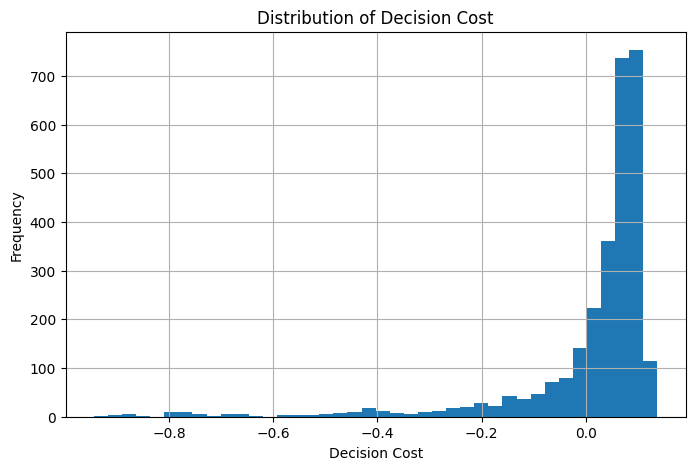

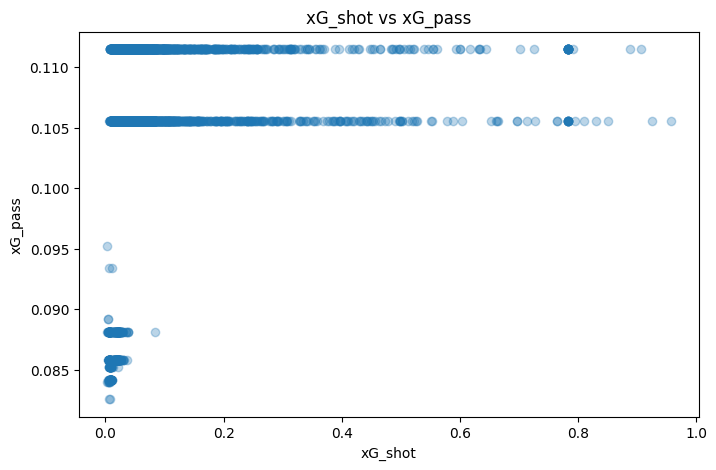

,player_name,num_shots,avg_decision_cost,total_decision_cost
85,Glenn Whelan,11,0.093667,1.030341
90,Harry Arter,36,0.083849,3.018551
0,Aaron Cresswell,27,0.080328,2.168855
34,Charlie Adam,28,0.076104,2.130912
1,Adam Smith,15,0.074169,1.112535
81,Gilbert Gianelli Imbula Wanga,21,0.074116,1.556442
101,Jack Frank Porteous Cork,19,0.069738,1.325014
10,Andrew Surman,16,0.069347,1.109552
282,Àngel Rangel Zaragoza,14,0.069276,0.969868
189,Modou Barrow,12,0.065183,0.782195


In [ ]:
# -----------------------------
# Cell 16: Descriptive analysis
# -----------------------------
import matplotlib.pyplot as plt

print("Summary stats:")
display(final_dataset[["shot_xg", "xG_pass", "delta", "context_factor", "decision_cost"]].describe())

# decision cost distribution
plt.figure(figsize=(8, 5))
final_dataset["decision_cost"].dropna().hist(bins=40)
plt.title("Distribution of Decision Cost")
plt.xlabel("Decision Cost")
plt.ylabel("Frequency")
plt.show()

# xG_shot vs xG_pass
plt.figure(figsize=(8, 5))
plt.scatter(
    final_dataset["shot_xg"],
    final_dataset["xG_pass"],
    alpha=0.3
)
plt.title("xG_shot vs xG_pass")
plt.xlabel("xG_shot")
plt.ylabel("xG_pass")
plt.show()

# top players by average decision cost (min 10 shots)
player_summary = (
    final_dataset
    .groupby("player_name", as_index=False)
    # Group the final_dataset by player_name to calculate summary statistics for each player based on their shot decisions, which will allow us to identify players with the highest average decision cost,
    #indicating potentially suboptimal shot choices compared to the average xG_pass for their shooting zones
    .agg(
        # Aggregate the decision_cost values for each player by calculating the number of shots, average decision cost,
        # and total decision cost to analyze the overall impact of their shot decisions and identify players who may have consistently made suboptimal choices based on the calculated decision cost metric
        num_shots=("decision_cost", "size"),
        avg_decision_cost=("decision_cost", "mean"),
        total_decision_cost=("decision_cost", "sum")
    )
)

player_summary_filtered = player_summary[player_summary["num_shots"] >= 10].copy()
player_summary_filtered = player_summary_filtered.sort_values("avg_decision_cost", ascending=False)

display(player_summary_filtered.head(15))

## Limitations and Reflection

This project uses publicly available event data to estimate shot decision quality. This design has practical advantages, but also several limitations:

1. StatsBomb open EPL event coverage is limited, so the event-level analysis window is narrower than the full 10-season results window.
2. The passing alternative is not directly observed as an actually available passing lane at the decision moment. Instead, it is estimated from historical pass-to-shot patterns within the same pitch zone.
3. League position and recent form are used as contextual proxies and may not fully represent true psychological or tactical pressure.
4. Event data does not provide full tracking information such as teammate and defender positions.

Despite these limitations, the workflow demonstrates a complete and justified data preparation pipeline:
profiling, structuring, enriching, cleaning, feature engineering, and construction of an analysis-ready shot-level dataset.


## Data Quality and Missing/Outlier Handling

To ensure that the data preparation pipeline is transparent and justified, we explicitly summarize how missing values and potential outliers were handled.

### Missing Values
We inspected key columns used in the final shot-level analytical dataset, including:
- spatial coordinates (`x`, `y`)
- shot value (`shot_xg`)
- team and player identifiers
- engineered contextual features such as `xG_pass`, `recent_form_5`, and `league_position`

Records with missing values in essential columns required for shot-level analysis were removed during earlier preparation steps. In particular:
- shots without valid spatial coordinates or missing `shot_xg` were excluded,
- passes without valid spatial coordinates were excluded,
- joins with results/context data may still lead to some missing contextual features if no suitable historical match state was available.

### Outliers and Small-Sample Issues
We also examined potential outliers in engineered variables, especially:
- `shot_xg`
- `xG_pass`
- `decision_cost`

In this project, extreme values are not automatically treated as errors, because some high-value or low-value football events may still be valid observations. Instead, we use profiling and summary statistics to identify unusual values and interpret them carefully.

A more important stability issue is small sample size at the zone level. Since `xG_pass` is estimated from historical pass-to-shot sequences, zones with very few samples may produce unstable averages. We therefore keep the sample count (`zone_pass_shot_samples`) in the final dataset so that low-support estimates can be recognized and discussed explicitly.

### Data Quality Note
This project uses multiple public data sources. As a result, some data quality issues arise from:
- limited event-data coverage in publicly available StatsBomb EPL data,
- naming mismatches across sources,
- contextual features that cannot always be perfectly aligned at every event timestamp.

These issues are handled through explicit cleaning, standardization, and cautious interpretation rather than being ignored.

**Main Purpose:** Validate final dataset integrity and identify anomalous records requiring investigation  
**What It Does:** Defines list of quality-critical columns; reports final dataset shape; calculates count and percentage of missing values for each column; generates numeric summary statistics; identifies rows with zone_pass_shot_samples below 5 (low-support estimates); identifies rows with extreme decision_cost values; displays preview of low-support and extreme cases  
**Benefits:** Ensures data quality before relying on analysis results; flags potentially unreliable zone estimates; identifies extreme cases deserving investigation; documents data completeness and reliability; helps distinguish genuine insights from artifacts

In [ ]:
# -----------------------------
# Data Quality Check: Missing values and potential outliers
# -----------------------------
quality_cols = [
    "x", "y", "shot_xg", "xG_pass", "delta",
    "recent_form_5", "league_position",
    "score_diff_before_shot", "context_factor", "decision_cost",
    "zone_pass_shot_samples"
]

quality_cols = [c for c in quality_cols if c in final_dataset.columns]

print("Final dataset shape:", final_dataset.shape)

print("\nMissing values summary:")
# Calculate the count and percentage of missing values for key columns in the final_dataset to assess data quality
# and identify any potential issues with missing data that may need to be addressed before analysis or modeling
missing_summary = (
    final_dataset[quality_cols]
    .isna() # Check for missing values in the specified quality columns to identify any gaps in the data that could affect analysis or modeling
    .sum() # Calculate the count of missing values for each quality column to understand the extent of missing data in each key feature
    .to_frame("missing_count") # Convert the Series of missing counts into a DataFrame for better presentation and to allow for additional calculations such as missing percentage
)
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(final_dataset) * 100).round(2)
display(missing_summary)

print("\nBasic numeric summary:")
display(final_dataset[quality_cols].describe())

print("\nRows with low-support zone estimates (zone_pass_shot_samples < 5):")
if "zone_pass_shot_samples" in final_dataset.columns: # Identify rows in the final_dataset where the zone_pass_shot_samples is less than 5 to flag potential low-support estimates for xG_pass by zone,
    # which may indicate that the xG_pass value for those zones is based on a small sample size and may be less reliable for analysis or modeling
    low_support = final_dataset[final_dataset["zone_pass_shot_samples"] < 5]
    print("Count:", len(low_support))
    display(low_support[[ # Display a preview of the rows with low-support zone estimates, showing key columns for analysis to understand which shots are affected by potentially unreliable xG_pass estimates due to small sample sizes in those zones
        c for c in [
            "player_name", "team_name", "zone",
            "shot_xg", "xG_pass", "zone_pass_shot_samples", "decision_cost"
        ] if c in low_support.columns
    ]].head(10))

print("\nPotential extreme decision_cost values (top 10 by absolute value):")
if "decision_cost" in final_dataset.columns:
    extreme_dc = final_dataset.loc[ # Identify rows in the final_dataset with the highest absolute values of decision_cost to flag potential extreme cases of suboptimal shot decisions, which may warrant further investigation to understand the context and reasons behind those decisions
        final_dataset["decision_cost"].abs().sort_values(ascending=False).index # Sort the final_dataset by the absolute value of decision_cost in descending order to identify the shots with the most extreme decision costs,
        # which could indicate particularly good or bad shot decisions based on the calculated metric
    ].head(10)
    display(extreme_dc[[ # Display a preview of the rows with extreme decision_cost values, showing key columns for analysis to understand the context of these extreme cases and to investigate whether they are due to data issues, outliers, or genuinely suboptimal shot decisions
        c for c in [
            "player_name", "team_name", "zone",
            "shot_xg", "xG_pass", "delta",
            "context_factor", "decision_cost", "zone_pass_shot_samples"
        ] if c in extreme_dc.columns # Display key columns for analysis in the extreme decision_cost cases to understand the factors contributing to these extreme values, such as the shot's xG, the average xG_pass for the zone, the delta, and the context factor, as well as the sample size for the zone's xG_pass estimate
    ]])

Final dataset shape: (2839, 29)

Missing values summary:


,missing_count,missing_pct
x,0,0.00
y,0,0.00
shot_xg,0,0.00
xG_pass,1,0.04
delta,1,0.04
recent_form_5,2839,100.00
league_position,2839,100.00
score_diff_before_shot,0,0.00
context_factor,0,0.00
decision_cost,1,0.04



Basic numeric summary:


,x,y,shot_xg,xG_pass,delta,recent_form_5,league_position,score_diff_before_shot,context_factor,decision_cost,zone_pass_shot_samples
count,2839.000000,2839.000000,2839.000000,2838.000000,2838.000000,0.0,0.0,2839.000000,2839.000000,2838.000000,2838.000000
mean,102.482600,39.728355,0.094804,0.105893,0.011055,NaN,NaN,0.113772,1.141043,0.012805,2970.139887
std,9.046572,9.953633,0.134213,0.007590,0.132878,NaN,NaN,1.092651,0.092799,0.152160,741.941223
min,35.400000,1.000000,0.000180,0.082583,-0.851689,NaN,NaN,-5.000000,0.980000,-0.944089,2596.000000
25%,95.900000,32.400000,0.025820,0.105515,0.009494,NaN,NaN,0.000000,1.080000,0.011092,2596.000000
50%,103.200000,39.800000,0.048891,0.105515,0.058697,NaN,NaN,0.000000,1.134000,0.066020,2813.000000
75%,109.900000,46.800000,0.099678,0.111473,0.077126,NaN,NaN,1.000000,1.176000,0.087149,2813.000000
max,120.200000,78.500000,0.957205,0.111473,0.104614,NaN,NaN,5.000000,1.344000,0.137297,5211.000000



Rows with low-support zone estimates (zone_pass_shot_samples < 5):
Count: 0


,player_name,team_name,zone,shot_xg,xG_pass,zone_pass_shot_samples,decision_cost



Potential extreme decision_cost values (top 10 by absolute value):


,player_name,team_name,zone,shot_xg,xG_pass,delta,context_factor,decision_cost,zone_pass_shot_samples
2052,Thierry Henry,Arsenal,Z3_2,0.906161,0.111473,-0.794688,1.188,-0.944089,2596.0
1629,Bafétimbi Gomis,Swansea City,Z3_1,0.957205,0.105515,-0.851689,1.080,-0.919825,2813.0
602,Bojan Krkíc Pérez,Stoke City,Z3_2,0.783500,0.111473,-0.672027,1.344,-0.903204,2596.0
2534,Massimo Maccarone,Middlesbrough,Z3_2,0.783500,0.111473,-0.672027,1.344,-0.903204,2596.0
1483,Gylfi Þór Sigurðsson,Swansea City,Z3_2,0.783500,0.111473,-0.672027,1.344,-0.903204,2596.0
2671,Nicolas Anelka,Manchester City,Z3_1,0.764752,0.105515,-0.659237,1.344,-0.886014,2813.0
1355,Andy Carroll,West Ham United,Z3_1,0.783500,0.105515,-0.677985,1.296,-0.878668,2813.0
628,Marko Arnautović,Stoke City,Z3_2,0.783500,0.111473,-0.672027,1.296,-0.870946,2596.0
2493,Ruud van Nistelrooy,Manchester United,Z3_2,0.783500,0.111473,-0.672027,1.296,-0.870946,2596.0
556,Marko Arnautović,Stoke City,Z3_2,0.783500,0.111473,-0.672027,1.296,-0.870946,2596.0


## Source Coverage Note and Scope Clarification

Our project combines multiple public data sources with different coverage characteristics.

### Results and Context Window
The match-results data from Football-Data.co.uk was expanded to a 10-season window. This broader time span supports:
- more robust league standing construction,
- recent-form estimation,
- better long-term contextual reasoning.

### Event-Level Analysis Window
The core shot-decision analysis depends on event-level data such as:
- shots,
- passes,
- possession sequences,
- shot xG,
- pitch locations.

These variables come from StatsBomb open event data. However, publicly available EPL event coverage in StatsBomb is more limited than the 10-season results window.

Therefore, the final event-level analysis is performed on the EPL seasons that are available in StatsBomb open data, while the broader 10-season results data is used to support contextual preparation and league-based enrichment where applicable.

### Justification
This design is still appropriate for the project because:
1. the event-level source is essential for constructing `xG_shot`, `xG_pass`, and possession-based pass-to-shot links,
2. the match-results source provides additional context not directly available in event data,
3. the notebook explicitly documents this source-coverage limitation instead of hiding it.

This reflects a justified source-selection decision under real public-data constraints.

**Main Purpose:** Document the data sources and temporal coverage used in the analysis  
**What It Does:** Prints unique season codes from football-data results dataset; displays EPL seasons from StatsBomb metadata including competition IDs, season IDs, and season names  
**Benefits:** Provides transparency on data sources and coverage; enables verification that all intended seasons were successfully loaded; creates audit trail for reproducibility; documents whether any seasons failed to load

In [ ]:
# -----------------------------
# Source coverage summary
# -----------------------------
print("Football-data seasons in results:")
if "results" in globals() and "season_code" in results.columns:
    print(sorted(results["season_code"].dropna().unique().tolist()))

print("\nStatsBomb EPL seasons used for event-level analysis:")
if "epl" in globals() and "season_name" in epl.columns:
    display(epl[["competition_id", "season_id", "season_name"]].drop_duplicates())

Football-data seasons in results:
['1415', '1516', '1617', '1718', '1819', '1920', '2021', '2122', '2223', '2324']

StatsBomb EPL seasons used for event-level analysis:


,competition_id,season_id,season_name
0,2,27,2015/2016
1,2,44,2003/2004
